Jack Porter Dissertation Code Submission

All imports required

In [1]:
# Installs
!apt-get update
!apt-get install -y default-jdk
!pip install pyterrier[java]
!pip install -q tiktoken
!pip install ir-datasets

# Imports
import ir_datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pyterrier as pt
import re
import seaborn as sns
import textwrap
import tiktoken
import time
import warnings
import zipfile

from collections import defaultdict
from email import message_from_string
from google import genai
from ir_measures import define_byquery
from matplotlib.colors import LogNorm
from pathlib import Path
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef
)
from statsmodels.stats.contingency_tables import mcnemar
from tqdm.auto import tqdm
from transformers import AutoTokenizer

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,803 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:14 h

Sara dataset including sensitivity labels

In [2]:
dataset = ir_datasets.load("sara")

Data Extraction and Label Preparation

This section converts the raw dataset into a structured format suitable for analysis. Each email is extracted and stored with its corresponding identifier, the text of the email, and sensitivity label.

The sensitivity variable is then transformed into a more interpretable categorical format (“yes” / “no”), which improves readability and facilitates downstream analysis. This step ensures consistency in how sensitive content is represented throughout the study.

In [3]:
docs = []
for doc in dataset.docs_iter():
    docs.append({
        "doc_id": doc.doc_id,
        "text": doc.text,
        "sensitivity": doc.sensitivity
    })

df_docs = pd.DataFrame(docs)

df_docs["true_label"] = df_docs["sensitivity"].map({0: "no", 1: "yes"})

[INFO] [starting] building docstore
[INFO] If you have a local copy of https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/f880a35b54bf9fa4d18d1eee8da6f179
[INFO] [starting] https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz
docs_iter:   0%|                                      | 0/1702 [00:00<?, ?doc/s]
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 0.0%| 0.00/4.52M [00:00<?, ?B/s]
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 2.2%| 98.3k/4.52M [00:00<00:07, 607kB/s]
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 5.8%| 262k/4.52M [00:00<00:04, 910kB/s] 
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 20.8%| 942k/4.52M [00:00<00:01, 2.22MB/s]

[INFO] [finished] https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: [00:00] [4.52MB] [7.56MB/s]
docs_iter:   0%|                                

Example of structure of the email data frame

In [4]:
df_docs.head()

,doc_id,text,sensitivity,true_label
0,114715,Message-ID: <26804150.1075842955435.JavaMail.e...,0,no
1,229405,Message-ID: <23075367.1075853128311.JavaMail.e...,0,no
2,232795,Message-ID: <27422646.1075853196172.JavaMail.e...,0,no
3,62815,Message-ID: <4131316.1075840896739.JavaMail.ev...,0,no
4,118871,Message-ID: <12747077.1075843316348.JavaMail.e...,0,no


Extracts the body of all emails in the dataset removing meta data

In [7]:

def extract_body(raw_email: str):
    msg = message_from_string(raw_email)

    if msg.is_multipart():
        parts = []
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                try:
                    parts.append(
                        part.get_payload(decode=True).decode(errors="ignore")
                    )
                except:
                    pass
        return "\n".join(parts)

    payload = msg.get_payload(decode=True)
    if payload:
        return payload.decode(errors="ignore")
    return msg.get_payload()

df_docs["body"] = df_docs["text"].apply(extract_body)

a fixed Development Set strategy was employed rather than a randomised split at runtime. This approach guarantees that the 100 samples (50 sensitive, 50 non-sensitive) used to derive the emotion and content based prompts remained consistent across all experimental iterations.

This development set included 50 sensitive and 50 non sensitive emails. The rest of the emails were in the test set.

In [8]:

dev_df = pd.read_csv('/content/drive/MyDrive/100_new_prompt.csv') # development set (50 sensitive 50 non sensitive), file too big to submit
test_df = df_docs[~df_docs['body'].isin(dev_df['body'])] # test set
dev_df = df_docs[df_docs['body'].isin(dev_df['body'])]
print(len(dev_df)) # Length of Development Set
print(len(test_df)) # Length of Test set before large emails are removed



100
1602


## Analysis of emotions linked to sensitivity

looked at emotions linked to sensitivity in the development set to create emotion signals for that method

The UC Berkeley emotion annotations are mapped to the emails in the development set to identify which emotions were most prevalent in sensitive versus non-sensitive emails. The emotions most associated with sensitive emails were then used to create the signal questions for the emotion and tone method.

In [9]:


!cp -r "/content/drive/MyDrive/enron_with_categories" "/content/enron_local"


BASE_DIR = "/content/enron_local"
EMOTION_MAPPING = {
    1: "Jubilation", 2: "Hope / anticipation", 3: "Humour", 4: "Camaraderie",
    5: "Admiration", 6: "Gratitude", 7: "Friendship / affection", 8: "Sympathy / support",
    9: "Sarcasm", 10: "Secrecy / confidentiality", 11: "Worry / anxiety", 12: "Concern",
    13: "Competitiveness / aggressiveness", 14: "Triumph / gloating", 15: "Pride",
    16: "Anger / agitation", 17: "Sadness / despair", 18: "Shame", 19: "Dislike / scorn"
}

rows = []

for shard in range(1, 9):
    shard_dir = os.path.join(BASE_DIR, str(shard))
    if not os.path.exists(shard_dir): continue

    for fname in os.listdir(shard_dir):
        if not fname.endswith(".cats"): continue

        # Parse Categories from UC berkeley dataset
        labels = defaultdict(int)
        with open(os.path.join(shard_dir, fname), "r") as f:
            for line in f:
                n1, n2, n3 = map(int, line.strip().split(","))
                labels[(n1, n2)] += n3

        # Extract Personal Metadata
        n12, n13 = labels.get((1, 2), 0), labels.get((1, 3), 0)
        is_personal = (n12 >= 1 or n13 >= 1)

        if n12 >= 1 and n13 >= 1: subtype = "ambiguous"
        elif n12 >= 1: subtype = "purely_personal"
        elif n13 >= 1: subtype = "personal_professional"
        else: subtype = "non_personal"

        # Read Text & Message-ID
        txt_path = os.path.join(shard_dir, fname.replace(".cats", ".txt"))
        with open(txt_path, "r", encoding="latin-1") as f:
            text = f.read()

        msg_id_match = re.search(r"Message-ID:\s*<([^>]+)>", text)
        message_id = msg_id_match.group(1) if msg_id_match else None

        # Build Row with Emotion Votes (n1 == 4)
        row = {
            "email_id": f"{shard}/{fname.replace('.cats','')}",
            "message_id": message_id,
            "is_personal": is_personal,
            "confidence": max(n12, n13) / 3.0,
            "subtype": subtype,
            "text": text
        }

        # Add all emotions (default to 0 if not present)
        for code, name in EMOTION_MAPPING.items():
            row[name] = labels.get((4, code), 0)

        rows.append(row)

df = pd.DataFrame(rows)

example of what dataset looks like with emotion labels

In [10]:
df.head()

,email_id,message_id,is_personal,confidence,subtype,text,Jubilation,Hope / anticipation,Humour,Camaraderie,...,Secrecy / confidentiality,Worry / anxiety,Concern,Competitiveness / aggressiveness,Triumph / gloating,Pride,Anger / agitation,Sadness / despair,Shame,Dislike / scorn
0,1/128901,10087910.1075851652393.JavaMail.evans@thyme,False,0.0,non_personal,Message-ID: <10087910.1075851652393.JavaMail.e...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1/218993,7559432.1075852469700.JavaMail.evans@thyme,False,0.0,non_personal,Message-ID: <7559432.1075852469700.JavaMail.ev...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1/116688,17090793.1075843014073.JavaMail.evans@thyme,False,0.0,non_personal,Message-ID: <17090793.1075843014073.JavaMail.e...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1/174397,104094.1075846176879.JavaMail.evans@thyme,False,0.0,non_personal,Message-ID: <104094.1075846176879.JavaMail.eva...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1/174266,27030787.1075846172842.JavaMail.evans@thyme,False,0.0,non_personal,Message-ID: <27030787.1075846172842.JavaMail.e...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Maps emotion labels to only the emails in the development set

In [11]:
def extract_message_id(text):
    match = re.search(r"Message-ID:\s*<([^>]+)>", text)
    return match.group(1) if match else None

dev_df["message_id"] = dev_df["text"].apply(extract_message_id)

emotions_dev_set = df[df["message_id"].isin(dev_df["message_id"])]

/tmp/ipykernel_8334/618199160.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_df["message_id"] = dev_df["text"].apply(extract_message_id)


This calculates the percentage of emails in the dataset that were labelled with each emotion label, grouped into non sensitive and sensitive groups. These percentages were used to create the emotion and tone signal questions for the method.

Selected signals:

Humour, Camaraderie, Admiration, Gratitude, Friendship/Affection, Sympathy/Support and Sarcasm.

In [12]:

emotion_cols = [col for col in df.columns if col not in ["email_id", "is_personal", "confidence", "subtype", "text", "message_id"]]

emotion_sums = (
    emotions_dev_set
    .groupby("is_personal")[emotion_cols]
    .sum()
)

emotion_percentages = (
    emotion_sums
    .div(50)
    * 100
).round(2)

emotion_percentages.index = emotion_percentages.index.map(
    {True: "Personal", False: "Non-personal"}
)

emotion_percentages


,Jubilation,Hope / anticipation,Humour,Camaraderie,Admiration,Gratitude,Friendship / affection,Sympathy / support,Sarcasm,Secrecy / confidentiality,Worry / anxiety,Concern,Competitiveness / aggressiveness,Triumph / gloating,Pride,Anger / agitation,Sadness / despair,Shame,Dislike / scorn
is_personal,,,,,,,,,,,,,,,,,,,
Non-personal,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Personal,4.0,2.0,20.0,8.0,4.0,2.0,12.0,2.0,4.0,8.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


## Token Size calculations

This code calculated the token size of each email using tiktoken

In [13]:


enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(enc.encode(text))

test_df["token_count"] = test_df["body"].apply(count_tokens)
df_docs["token_count"] = df_docs["body"].apply(count_tokens)




/tmp/ipykernel_8334/1448342370.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["token_count"] = test_df["body"].apply(count_tokens)


All emails above 14000 tokens were removed as they cannot be processed by the LLM

In [14]:
test_small_df = test_df[test_df["token_count"] <= 14000]
print(len(test_small_df))

1538


Emails in test set were split into buckets based off token size. As smaller emails can be processed quicker by the LLM

In [15]:
bucket_2000 = test_small_df[test_small_df["token_count"] <= 2000]
bucket_3500 = test_small_df[(test_small_df["token_count"] > 2000) & (test_small_df["token_count"] <= 3500)]
bucket_rest = test_small_df[test_small_df["token_count"] > 3500]

print(len(bucket_2000))
print(len(bucket_3500))
print(len(bucket_rest))

1474
37
27








Initialises the Google GenAI client to access the Gemma-3-4b-it model via Google AI Studio.

In [ ]:

client = genai.Client(api_key="")

Context given to all decomposed methods in prompt

In [ ]:
GLOBAL_CONTEXT = """
You are analysing an email from the Enron corporate email dataset.

The task is to support sensitivity classification under the SARA definition.
An email is considered sensitive only if it is either:
Purely Personal, or Personal in a Professional Context.

Emails that are purely professional, organisational, or logistical are not sensitive,
even if they contain confidential business information or internal company matters.

You will be asked a sequence of yes/no questions.
Answer each question independently, based only on the email content.
Respond only with "Yes" or "No".

"""

Combines prompt of context, question and email body. Then sends prompt to the LLM to get a prediction.

In [ ]:
def ask_question(email_body, question_text, model_name):
    prompt = (
        GLOBAL_CONTEXT
        + question_text
        + "\n\nHere is the email:\n"
        + email_body
    )

    response = client.models.generate_content(
        model=model_name,
        contents=prompt
    )

    return response.text.strip()


To iterate through the dataset and systematically query the LLM for each email while ensuring data persistence and error recovery.

Key Features of the Execution Logic:

Checkpoint & Resume: The function checks if an output file already exists. If the process is interrupted, it resumes from the last unsaved row rather than starting over, saving time and API costs.

Rate Limit Management: It incorporates a sleep_time (default 8 seconds) between API calls. This is a crucial to stay within the model provider’s Rate Limits.

Batch Saving: Instead of saving only at the very end, it performs a periodic save (every 50 rows). This ensures that even in the event of a runtime crash, the majority of the processed data is preserved.

Error Handling: It uses a try-except block to catch specific API or connection failures. If a single email fails, the code marks it as an "error" and moves to the next, preventing one bad data point from stopping the entire research pipeline.
.

In [ ]:

def run_questionnaire(
    df,
    output_path,
    model_name="gemma-3-4b-it",
    sleep_time=8,
    block_size=50
):
    # If output exists, resume from it
    if os.path.exists(output_path):
        df_out = pd.read_csv(output_path)
        print(f"Resuming from existing file: {output_path}")
    else:
        df_out = df.copy()
        for q_id in QUESTIONS:
            df_out[q_id] = None

    processed = 0

    for idx, row in tqdm(df_out.iterrows(), total=len(df_out)):
        # Skip rows where all questions are already answered
        if all(pd.notna(row[q_id]) for q_id in QUESTIONS):
            continue

        email_text = row["body"]

        for q_id, q_text in QUESTIONS.items():
            # Skip questions already answered
            if pd.notna(row[q_id]):
                continue

            try:
                answer = ask_question(email_text, q_text, model_name)
                df_out.at[idx, q_id] = answer

            except Exception as e:
                print(f"Error on row {idx}, question {q_id}: {e}")
                df_out.at[idx, q_id] = "error"

            time.sleep(sleep_time)

        processed += 1

        # Save progress every block_size rows
        if processed % block_size == 0:
            df_out.to_csv(output_path, index=False)
            print(f"Saved progress at {processed} processed rows")

    # Final save
    df_out.to_csv(output_path, index=False)
    print("Final save complete.")

    return df_out


Prompt used for the method deriving signals from external PII taxonomies

In [ ]:
tax_demographic_social = """
Does the email mention demographic, family-related, social, or cultural information about an identifiable individual?

This includes references to age, date of birth, marital status, children, nationality, ethnicity, cultural background, language, education history, or social status when discussed about a specific person.

Answer Yes if the email contains personal demographic, social, or cultural details about an individual.
Answer No if no such information is present.
"""

tax_belief = """
Does the email mention political or religious beliefs, affiliations, or activities related to an identifiable individual?

This includes references to political parties, voting preferences, political activism, public office, religious beliefs, faith, religious practices, or membership in religious organisations when linked to a specific person.

Answer Yes if political or religious personal information about an individual is present.
Answer No if it is not.
"""

tax_legal = """
Does the email mention legal, disciplinary, or formal employment-related proceedings involving an identifiable individual?

This includes references to investigations, complaints, disciplinary actions, grievances, lawsuits, formal warnings, or trade union involvement such as representation, industrial action, or union-related leave when linked to a specific person.

Answer Yes if legal, disciplinary, or union-related personal information is discussed.
Answer No if it is not.
"""

tax_health = """
Does the email mention health-related information about an identifiable individual?

This includes references to illness, injury, disability, medical conditions, mental health issues, sick leave, recovery, treatment, or health-related absence.

Answer Yes if personal health information is discussed.
Answer No if no health-related personal information is present.
"""

tax_financial = """
Does the email disclose personal financial information about an identifiable individual?

This includes references to salary, pay disputes, bonuses, debts, personal bank details, credit issues, or financial obligations related to a specific person.

Answer Yes if personal financial information is present.
Answer No if it is not.
"""

tax_contact = """
Does the email include personal contact details of an identifiable individual outside of work?

This includes private phone numbers, personal email addresses, home addresses, or contact details shared in a personal or non-routine context.

Answer Yes if personal contact information is disclosed in a personal context.
Answer No if contact details are purely professional or appear only in standard email signatures.
"""






Stores all questions for external PII taxonomies in dictionary

In [ ]:
QUESTIONS = {
    "q_demographic_social": tax_demographic_social,
    "q_belief": tax_belief,
    "q_legal": tax_legal,
    "q_health": tax_health,
    "q_financial": tax_financial,
    "q_contact": tax_contact,
}

Runs code for each bucket using external PII taxonomy questions, storing results in external files.

In [ ]:
output_path = "/content/drive/MyDrive/tax_2000.csv"
tax_2000 = run_questionnaire(
    bucket_2000,
    output_path=output_path,
    sleep_time=8,
    block_size=10
)

output_path = "/content/drive/MyDrive/tax_3500.csv"
tax_3500 = run_questionnaire(
    bucket_3500,
    output_path=output_path,
    sleep_time=16,
    block_size=10
)

output_path = "/content/drive/MyDrive/tax_rest.csv"
tax_rest = run_questionnaire(
    bucket_rest,
    output_path=output_path,
    sleep_time=60,
    block_size=10
)

  0%|          | 0/1474 [00:00<?, ?it/s]

KeyboardInterrupt: 

Full prompt for emotion and tone signals method

In [ ]:
humour_emotion = """
Does the email contain humour, joking, or playful language between individuals or in a personal situation?
Answer with only "Yes" or "No".
"""

friendship_emotion = """
Does the email contain expressions of personal closeness, friendship, affection, or emotional warmth between individuals that go beyond a purely professional relationship?
Answer with only "Yes" or "No".
"""

camaraderie_emotion = """
Does the email show camaraderie or a sense of shared group bonding beyond purely professional collaboration?
Answer with only "Yes" or "No".
"""

sarcasm_emotion = """
Does the email contain sarcasm, mocking language, or ironic comments intended to belittle or tease someone?
Answer with only "Yes" or "No".
"""

jubilation_emotion = """
Does the email contain expressions of jubilation, celebration, excitement, or triumphant happiness?
Answer with only "Yes" or "No".
"""

admiration_emotion = """
Does the email contain expressions of admiration, praise, or respect directed toward a person’s character, abilities, or achievements?
Answer with only "Yes" or "No".
"""

sympathy_support_emotion = """
Does the email contain expressions of sympathy, emotional support, concern, or comfort for someone’s personal situation?
Answer with only "Yes" or "No".
"""

gratitude_emotion = """
Does the email contain expressions of personal gratitude or thanks that suggest a personal relationship or personal favour, rather than routine workplace politeness?
Answer with only "Yes" or "No".
"""

Stores all questions for emotion and tone signals in dictionary

In [ ]:
QUESTIONS = {
    "q_humour": humour_emotion,
    "q_friendship": friendship_emotion,
    "q_gratitude": gratitude_emotion,
    "q_camaraderie": camaraderie_emotion,
    "q_sarcasm": sarcasm_emotion,
    "q_admiration": admiration_emotion,
    "q_sympathy": sympathy_support_emotion,
    "q_jubilation": jubilation_emotion
}



Runs code for each bucket using emotion questions, storing results in external files.

In [ ]:
output_path = "/content/drive/MyDrive/emotion_2000.csv"
emotion_2000 = run_questionnaire(
    bucket_2000,
    output_path=output_path,
    sleep_time=8,
    block_size=10
)

output_path = "/content/drive/MyDrive/emotion_3500.csv"
emotion_3500 = run_questionnaire(
    bucket_3500,
    output_path=output_path,
    sleep_time=16,
    block_size=10
)

output_path = "/content/drive/MyDrive/emotion_rest.csv"
emotion_rest = run_questionnaire(
    bucket_rest,
    output_path=output_path,
    sleep_time=60,
    block_size=10
)

  0%|          | 0/1474 [00:00<?, ?it/s]

KeyboardInterrupt: 

Questions for expert content based signals derived from development set

In [ ]:
pp_personal_life = """
Does the email mention personal life details, personal circumstances, or private matters about an identifiable individual?

This includes references to family or relationships, social life, health or illness, emotional struggles, personal problems, life events (such as birthdays, ageing, children, bereavement), personal opinions unrelated to work, or informal personal exchanges that do not serve a professional or organisational purpose.

Answer Yes if the email discusses private, non-work aspects of an individual’s life.
Answer No if the email does not include personal life information.
"""

pp_personal_humour = """
Does this email contain non-work-related humour or informal personal conversation that does not serve a business or organisational purpose?

This includes jokes, playful banter, sarcasm, “dad jokes”, memes or gifs intended for amusement or friendly exchanges that are unrelated to completing a work task or making a business decision.

Answer Yes if the email:
contains humour or informal conversation and it is not connected to a professional objective.
Answer No if:
the tone is professional, task-oriented, or serious.
"""


pip_personal_travel_social = """
Does this email include personal travel arrangements or social invitations that are not required for completing work duties?

Answer Yes if the email includes:
Personal travel plans unrelated to official business responsibilities
Invitations to social events such as lunches, dinners, drinks, celebrations, or informal gatherings
Conference or event invitations where attendance is framed as optional, social, or personally motivated
Travel or event participation organised for an individual’s personal benefit rather than a clear business requirement

Answer No if the email includes:
Travel arrangements made explicitly for company business or operational needs
Required attendance at work meetings, site visits, or formally assigned conferences
Logistical coordination (flights, hotels, schedules) clearly tied to professional duties
Routine business travel planning without personal or social framing
"""


pip_job_related = """
Does the email discuss an individual’s job prospects, career history, referrals, CVs, interviews, or hiring decisions?

Answer Yes if the email includes:
Discussion of job applications, CVs/resumés, or cover letters of an identifiable individual
References to interviews, shortlisting, offers, rejections, or hiring decisions
Referrals, recommendations, or endorsements of specific individuals
Commentary on an individual’s career history, performance, suitability, or future prospects
Internal discussions about promotions, transfers, role changes, or termination relating to named or identifiable individuals

Answer No if:
The email discusses general recruitment policies, hiring strategy, or workforce planning without reference to individuals
The content is purely administrative (e.g. posting a vacancy, scheduling interviews without personal detail)
No individual’s career or employment situation is discussed
"""

pip_opinions = """
Does the email express an opinion, judgement, or evaluation about an identifiable individual?

This includes personal opinions about colleagues or other named individuals, assessments of behaviour, performance, suitability for a role, or commentary on actions taken. It also covers any evaluative statements or critiques directed at an individual rather than at work outputs, projects, or general business matters.

Answer Yes if the email contains explicit or implied personal evaluations of an identifiable person.
Answer No if the email does not discuss an individual’s personal qualities, behaviour, performance, or suitability.
"""

Stores all questions for expert-derived signals in dictionary

In [ ]:

QUESTIONS = {
    "q_pp_personal_life": pp_personal_life,
    "q_pp_personal_humour": pp_personal_humour,
    "q_travel": pip_personal_travel_social,
    "q_job": pip_job_related,
    "q_opinions": pip_opinions
}


Runs code for each bucket using expert-derived questions, storing results in external files.

In [ ]:
output_path = "/content/drive/MyDrive/dev_2000.csv"
dev_2000 = run_questionnaire(
    bucket_2000,
    output_path=output_path,
    sleep_time=8,
    block_size=10
)

output_path = "/content/drive/MyDrive/dev_3500.csv"
dev_3500 = run_questionnaire(
    bucket_3500,
    output_path=output_path,
    sleep_time=16,
    block_size=10
)

output_path = "/content/drive/MyDrive/dev_rest.csv"
dev_rest = run_questionnaire(
    bucket_rest,
    output_path=output_path,
    sleep_time=60,
    block_size=10
)

Resuming from existing file: /content/drive/MyDrive/dev_2000.csv


  0%|          | 0/209 [00:00<?, ?it/s]

Final save complete.
Resuming from existing file: /content/drive/MyDrive/dev_3500.csv


  0%|          | 0/37 [00:00<?, ?it/s]

Final save complete.
Resuming from existing file: /content/drive/MyDrive/dev_rest.csv


  0%|          | 0/27 [00:00<?, ?it/s]

Final save complete.


Combines predictions from each each bucket back into full test set containing all predictions for each question. Each dataframe is all the responses for that particular method

In [ ]:
tax_full = pd.concat(
    [tax_2000, tax_3500, tax_rest],
    ignore_index=True
)

emotions_full = pd.concat(
    [emotion_2000, emotion_3500, emotion_rest],
    ignore_index=True
)

dev_full = pd.concat(
    [dev_2000, dev_3500, dev_rest],
    ignore_index=True
)


NameError: name 'tax_2000' is not defined

Loads in LLM predictions for each method. These files were too large to upload

In [16]:


dev_full = pd.read_csv('/content/drive/MyDrive/dev_full_updated.csv') #expert-derived predictions
tax_full = pd.read_csv('/content/drive/MyDrive/tax_full.csv') #PII taxonomy predictions
emotions_full = pd.read_csv('/content/drive/MyDrive/emotions_full_updated.csv') #Emotion Tone Predictions


Column names in df for all predictions per method

In [17]:
tax_columns = [
    "q_demographic_social",
    "q_belief",
    "q_legal",
    "q_health",
    "q_financial",
    "q_contact",
]

EMOTION_COLUMNS = [
    "q_humour",
    "q_friendship",
    "q_gratitude",
    "q_camaraderie",
    "q_sarcasm",
    "q_admiration",
    "q_sympathy",
    "q_jubilation"
]

dev_columns = [
    "q_pp_personal_life",
    "q_pp_personal_humour",
    "q_travel",
    "q_job",
    "q_opinions"
]


**OR Gate final classification strategy**

Sets email as sensitive if any of signal questions responded yes

In [18]:
def check_any_yes(row, columns_to_check):
    return "yes" if any(str(row[col]).strip().lower() == "yes" for col in columns_to_check) else "no"

tax_full['sara'] = tax_full.apply(
    lambda row: check_any_yes(row, tax_columns),
    axis=1
)

emotions_full['sara'] = emotions_full.apply(
    lambda row: check_any_yes(row, EMOTION_COLUMNS),
    axis=1
)

dev_full['sara'] = dev_full.apply(
    lambda row: check_any_yes(row, dev_columns),
    axis=1
)


print(tax_full["sara"].head())

0     no
1    yes
2    yes
3    yes
4     no
Name: sara, dtype: object


Evaluate performance of each method on test set for BAC, recall, precision and F1

In [19]:
def evaluate_sara(
    df,
    true_col="true_label",
    pred_col="sara",
    pos_label="yes"
):
    y_true = df[true_col]
    y_pred = df[pred_col]

    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=pos_label)
    recall = recall_score(y_true, y_pred, pos_label=pos_label)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label)

    return {
    "balanced_accuracy": float(balanced_accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1)
  }



## Primary Research Question

Performance for each approach on entire test set

In [20]:
print(f"PII taxonomy method performance: {evaluate_sara(tax_full)}")
print(f"Emotions method performance: {evaluate_sara(emotions_full)}")
print(f"Expert-derived method performance: {evaluate_sara(dev_full)}")

PII taxonomy method performance: {'balanced_accuracy': 0.5526829939460649, 'precision': 0.12463343108504399, 'recall': 0.5379746835443038, 'f1': 0.20238095238095238}
Emotions method performance: {'balanced_accuracy': 0.6309438635112823, 'precision': 0.18240343347639484, 'recall': 0.5379746835443038, 'f1': 0.2724358974358974}
Expert-derived method performance: {'balanced_accuracy': 0.6134608328747019, 'precision': 0.15074626865671642, 'recall': 0.6392405063291139, 'f1': 0.24396135265700483}


Confusion matrix for each method

In [21]:


def print_confusion_matrix(df, true_col="true_label", pred_col=""):

    cm = pd.crosstab(
        df[true_col],
        df[pred_col],
        rownames=["True label"],
        colnames=["Predicted label"]
    )

    print("\nConfusion Matrix:")
    print(cm)

print("External PII taxonomy Method")
print_confusion_matrix(tax_full, pred_col="sara")
print("emotion and tone Method")
print_confusion_matrix(emotions_full, pred_col="sara")
print("expert-derived Method")
print_confusion_matrix(dev_full, pred_col="sara")


External PII taxonomy Method

Confusion Matrix:
Predicted label   no  yes
True label               
no               783  597
yes               73   85
emotion and tone Method

Confusion Matrix:
Predicted label   no  yes
True label               
no               999  381
yes               73   85
expert-derived Method

Confusion Matrix:
Predicted label   no  yes
True label               
no               811  569
yes               57  101


## Mcnemars Significance Test

Performs a McNemars significance test to compare the differences in performance of the methods

In [22]:
def mcnemar_comparison(baseline_df, other_df, exact=True):
    y_true = baseline_df["true_label"].values

    base_pred = baseline_df["sara"].values
    other_pred = other_df["sara"].values

    base_correct = (base_pred == y_true)
    other_correct = (other_pred == y_true)

    a = np.sum(base_correct & other_correct)
    b = np.sum(base_correct & ~other_correct)
    c = np.sum(~base_correct & other_correct)
    d = np.sum(~base_correct & ~other_correct)

    table = [[a, b],
             [c, d]]

    result = mcnemar(table, exact=exact)

    return {
        "table": table,
        "b": b,
        "c": c,
        "p_value": result.pvalue
    }


Calculates if differences in performance between PII taxonomy method and Expert-derived method are significant

Calculates if differences in performance between emotion method and expert-derived are significant

Calculates if differences in performance between external taxonomy and emotion tone are significant

In [23]:
results = {}

results["External Taxonomy vs Expert"] = mcnemar_comparison(
    tax_full,
    dev_full
)

results["Expert vs Emotion Tone"] = mcnemar_comparison(
    dev_full,
    emotions_full
)

results["External Taxonomy vs Emotion Tone"] = mcnemar_comparison(
    tax_full,
    emotions_full
)

for model, res in results.items():
    print(f"\n{model}")
    print(f"Contingency table: {res['table']}")
    print(f"b (first method correct, second wrong): {res['b']}")
    print(f"c (first method wrong, second correct): {res['c']}")
    print(f"p-value: {res['p_value']:.4f}")

    if res["p_value"] < 0.05:
        print("→ Statistically significant difference")
    else:
        print("→ No statistically significant difference")


External Taxonomy vs Expert
Contingency table: [[np.int64(611), np.int64(257)], [np.int64(301), np.int64(369)]]
b (first method correct, second wrong): 257
c (first method wrong, second correct): 301
p-value: 0.0686
→ No statistically significant difference

Expert vs Emotion Tone
Contingency table: [[np.int64(782), np.int64(130)], [np.int64(302), np.int64(324)]]
b (first method correct, second wrong): 130
c (first method wrong, second correct): 302
p-value: 0.0000
→ Statistically significant difference

External Taxonomy vs Emotion Tone
Contingency table: [[np.int64(686), np.int64(182)], [np.int64(398), np.int64(272)]]
b (first method correct, second wrong): 182
c (first method wrong, second correct): 398
p-value: 0.0000
→ Statistically significant difference


## Secondary Research Question 1: Threshold Analysis

First, it creates a score for every email by adding up how many sub-questions received a "Yes" Then, it creates several new columns (labeled 1+ through 8+) to test different levels of strictness. For example, a "sara_3plus" label only marks an email as sensitive if the LLM found at least three different emotional signals. This allows us to compare different thresholds for the final classification strategy

In [24]:
def count_row_emotions(row):
    return sum(row[col] == "Yes" for col in EMOTION_COLUMNS)

def count_row_dev(row):
    return sum(row[col] == "Yes" for col in dev_columns)

def count_row_tax(row):
  return sum(row[col] == "Yes" for col in tax_columns)


emotions_full["num_emotions_yes"] = emotions_full.apply(count_row_emotions, axis=1)
dev_full["num_dev_yes"] = dev_full.apply(count_row_dev, axis=1)
tax_full["num_tax_yes"] = tax_full.apply(count_row_tax, axis=1)


for k in range(1, 9):
    emotions_full[f"sara_{k}plus"] = emotions_full["num_emotions_yes"].ge(k).map({True: "yes", False: "no"})
    dev_full[f"sara_{k}plus"] = dev_full["num_dev_yes"].ge(k).map({True: "yes", False: "no"})
    tax_full[f"sara_{k}plus"] = tax_full["num_tax_yes"].ge(k).map({True: "yes", False: "no"})


Calculates the performance of each method for each threshold

In [25]:
def evaluate_thresholds(df, true_col="true_label"):
    results = []

    y_true = df[true_col].map({"yes": 1, "no": 0})

    for k in range(1, 9):
        pred_col = f"sara_{k}plus"
        y_pred = df[pred_col].map({"yes": 1, "no": 0})

        results.append({
            "threshold": f"{k}+ yesses",
            "BAC": balanced_accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
        })

    return pd.DataFrame(results)
print("External Taxonomies Performance:")
print(evaluate_thresholds(tax_full))
print("\nEmotion and Tone Performance:")
print(evaluate_thresholds(emotions_full))
print("\nExpert-Derived:")
print(evaluate_thresholds(dev_full))


External Taxonomies Performance:
   threshold       BAC  Precision    Recall        F1
0  1+ yesses  0.552683   0.124633  0.537975  0.202381
1  2+ yesses  0.519258   0.136646  0.139241  0.137931
2  3+ yesses  0.506380   0.128571  0.056962  0.078947
3  4+ yesses  0.509833   0.170732  0.044304  0.070352
4  5+ yesses  0.495194   0.043478  0.006329  0.011050
5  6+ yesses  0.498817   0.076923  0.006329  0.011696
6  7+ yesses  0.500000   0.000000  0.000000  0.000000
7  8+ yesses  0.500000   0.000000  0.000000  0.000000

Emotion and Tone Performance:
   threshold       BAC  Precision    Recall        F1
0  1+ yesses  0.630944   0.182403  0.537975  0.272436
1  2+ yesses  0.618689   0.244726  0.367089  0.293671
2  3+ yesses  0.587282   0.294574  0.240506  0.264808
3  4+ yesses  0.552229   0.314286  0.139241  0.192982
4  5+ yesses  0.532444   0.351351  0.082278  0.133333
5  6+ yesses  0.510750   0.263158  0.031646  0.056497
6  7+ yesses  0.506233   0.250000  0.018987  0.035294
7  8+ yesses  0.50

Displays performance of each method across different classification thresholds

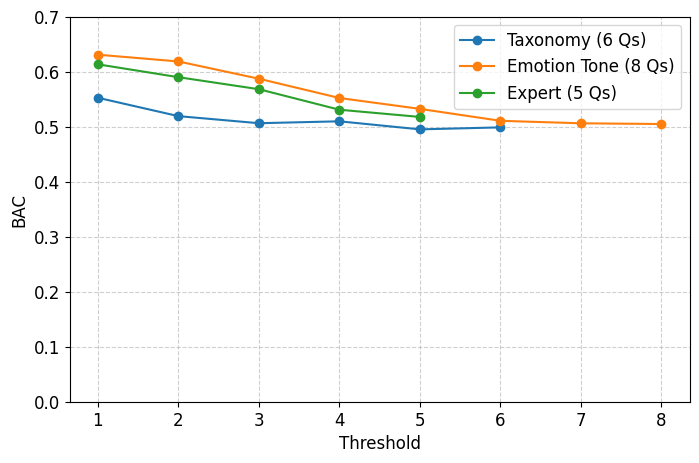

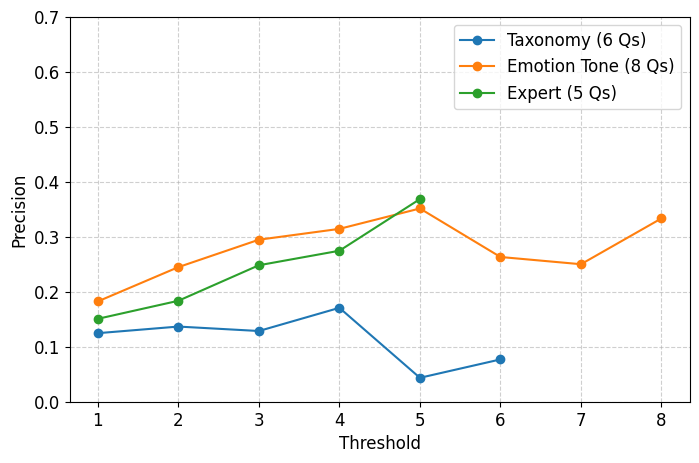

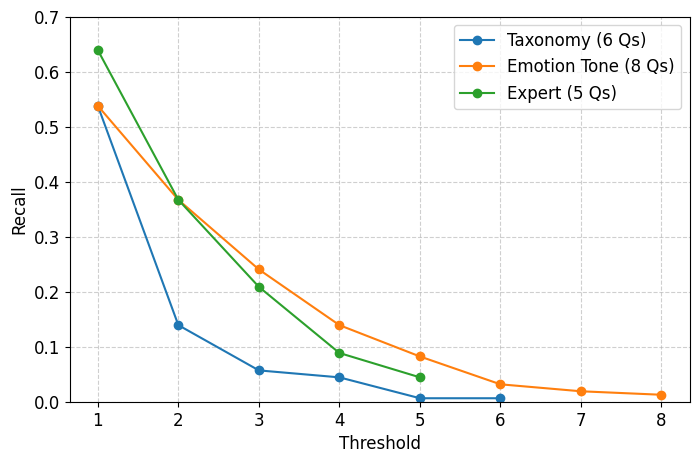

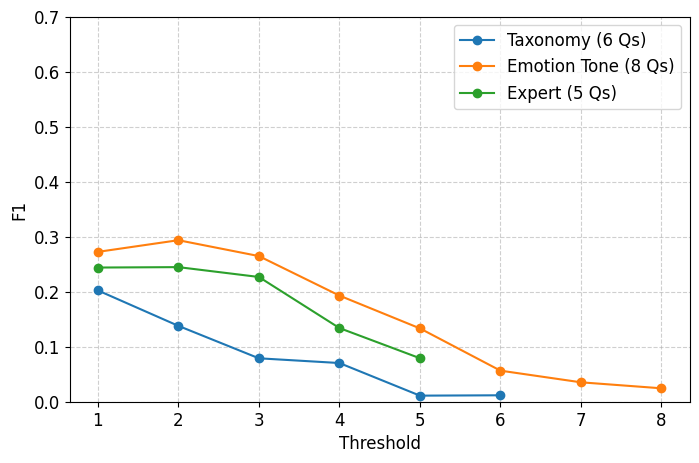

In [26]:
results_tax = evaluate_thresholds(tax_full).iloc[:6]  # Stop at 6
results_em = evaluate_thresholds(emotions_full)      # Stays at 8
results_dev = evaluate_thresholds(dev_full).iloc[:5]  # Stop at 5

metrics = ["BAC", "Precision", "Recall", "F1"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.rcParams.update({'font.size': 12})

    # Plot Taxonomy (1-6)
    plt.plot(range(1, 7), results_tax[metric], marker='o', label="Taxonomy (6 Qs)")

    # Plot Emotion Tone (1-8)
    plt.plot(range(1, 9), results_em[metric], marker='o', label="Emotion Tone (8 Qs)")

    # Plot Development Set (1-5)
    plt.plot(range(1, 6), results_dev[metric], marker='o', label="Expert (5 Qs)")

    plt.xlabel("Threshold")
    plt.ylabel(metric)
    plt.ylim(0, 0.7)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.savefig(f"{metric}_vs_Threshold.png", bbox_inches='tight')
    plt.show()


## Secondary Research Question: Email Category Analysis

It goes through a folder of Enron emails and, for every email, it pulls out the actual text from a .txt file and the human labels from a .cat file. Since the human labels are stored as a list of numbers (like "Category 1, Sub-category 2"), the code creates a dedicated column for every possible label and marks it with a 1 if the email has that tag and a 0 if it doesn't.

This is done to get the annotated labels for each email, so we can analyse performance on individual categories.

In [ ]:

#UC Berkeley labelled emails. each email has a .cats file containing the annotated labels
# and a .txt containing the text of the email
BASE_DIR = "/content/drive/MyDrive/enron_with_categories"

LABEL_RANGES = {
    1: range(1, 9),    # 1.1 - 1.8
    2: range(1, 14),   # 2.1 - 2.13
    3: range(1, 14),   # 3.1 - 3.13
    4: range(1, 20)    # 4.1 - 4.19
}

# Returns a dict of (n1, n2): votes for one email, filtering by threshold
def parse_email_labels(cats_path, threshold=1):
    labels = defaultdict(int)
    with open(cats_path, "r") as f:
        for line in f:
            n1, n2, votes = map(int, line.strip().split(","))
            if votes >= threshold:
                labels[(n1, n2)] = votes
    return labels

def extract_message_id(text):
    match = re.search(r"Message-ID:\s*<([^>]+)>", text)
    return match.group(1) if match else None

rows = []

for shard in range(1, 9):
    shard_dir = os.path.join(BASE_DIR, str(shard))
    for fname in os.listdir(shard_dir):
        if not fname.endswith(".cats"):
            continue

        cats_path = os.path.join(shard_dir, fname)
        txt_path = os.path.join(shard_dir, fname.replace(".cats", ".txt"))

        labels = parse_email_labels(cats_path, threshold=1)

        with open(txt_path, "r", encoding="latin-1") as f:
            text = f.read()

        email_id = f"{shard}/{fname.replace('.cats','')}"
        message_id = extract_message_id(text)

        rows.append({
            "email_id": email_id,
            "message_id": message_id,
            "labels": labels,
            "text": text
        })

df = pd.DataFrame(rows)

df = df[[col for col in df.columns if col not in [c for c in df.columns if c.startswith("label_")]]]

labels_expanded = pd.DataFrame([
    {f"label_{n1}_{n2}": int((n1, n2) in row_labels)
     for n1, n2_list in LABEL_RANGES.items()
     for n2 in n2_list}
    for row_labels in df["labels"]
], index=df.index)

# Concatenate with original df
df = pd.concat([df, labels_expanded], axis=1)

print("Total emails loaded:", len(df))
print("Number of label columns:", len([c for c in df.columns if c.startswith("label_")]))
print("First row labels:")
print(df.loc[0, [c for c in df.columns if c.startswith("label_")]])


Total emails loaded: 1702
Number of label columns: 53
First row labels:
label_1_1     1
label_1_2     0
label_1_3     0
label_1_4     0
label_1_5     0
label_1_6     0
label_1_7     0
label_1_8     0
label_2_1     0
label_2_2     0
label_2_3     0
label_2_4     0
label_2_5     0
label_2_6     0
label_2_7     0
label_2_8     0
label_2_9     0
label_2_10    0
label_2_11    0
label_2_12    0
label_2_13    0
label_3_1     0
label_3_2     0
label_3_3     0
label_3_4     0
label_3_5     1
label_3_6     0
label_3_7     0
label_3_8     0
label_3_9     1
label_3_10    0
label_3_11    0
label_3_12    0
label_3_13    0
label_4_1     0
label_4_2     0
label_4_3     0
label_4_4     0
label_4_5     0
label_4_6     0
label_4_7     0
label_4_8     0
label_4_9     0
label_4_10    0
label_4_11    0
label_4_12    0
label_4_13    0
label_4_14    0
label_4_15    0
label_4_16    0
label_4_17    0
label_4_18    0
label_4_19    0
Name: 0, dtype: object


Adds the human annotated labels to the results data frames for each method.

In [ ]:
def extract_message_id(text):
    match = re.search(r"Message-ID:\s*<([^>]+)>", text)
    return match.group(1) if match else None

# List of method DataFrames
method_dfs = [dev_full, tax_full, emotions_full]

# Label columns in df
label_cols = [c for c in df.columns if c.startswith("label_")]

for method_df in method_dfs:
    method_df["message_id"] = method_df["text"].apply(extract_message_id)

    method_df[label_cols] = method_df.merge(
        df[["message_id"] + label_cols],
        on="message_id",
        how="left"
    )[label_cols]

    method_df[label_cols] = method_df[label_cols].fillna(0).astype(int)


Calculates the performance for each method on each email category. Orders categories from lowest ratio of sensitive emails in the category to highest ratio of sensitive emails in the category, across the x axis. Colours each point based off the number of emails in the category. One plot for each metric including MCC.

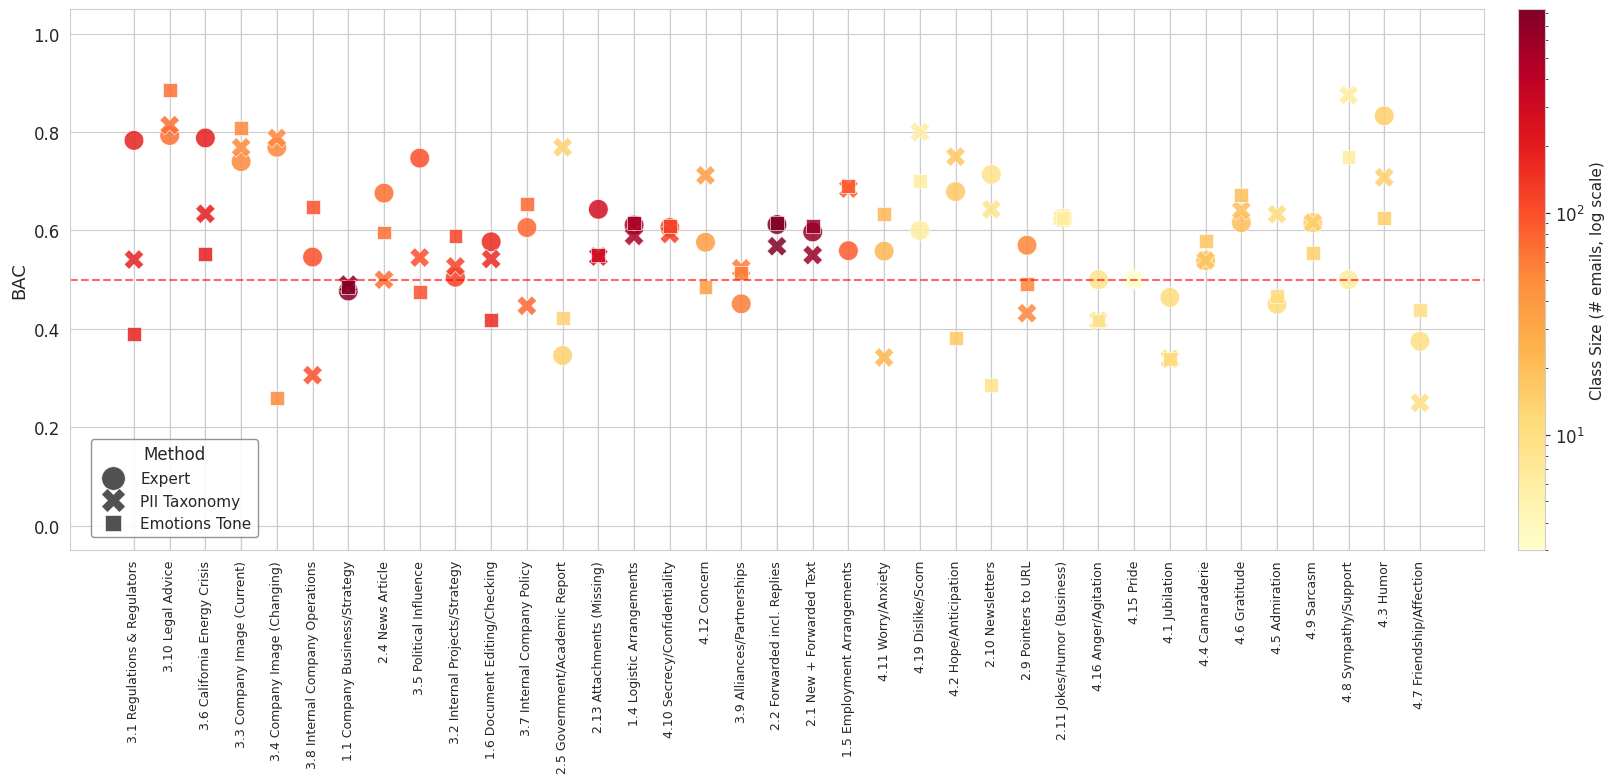

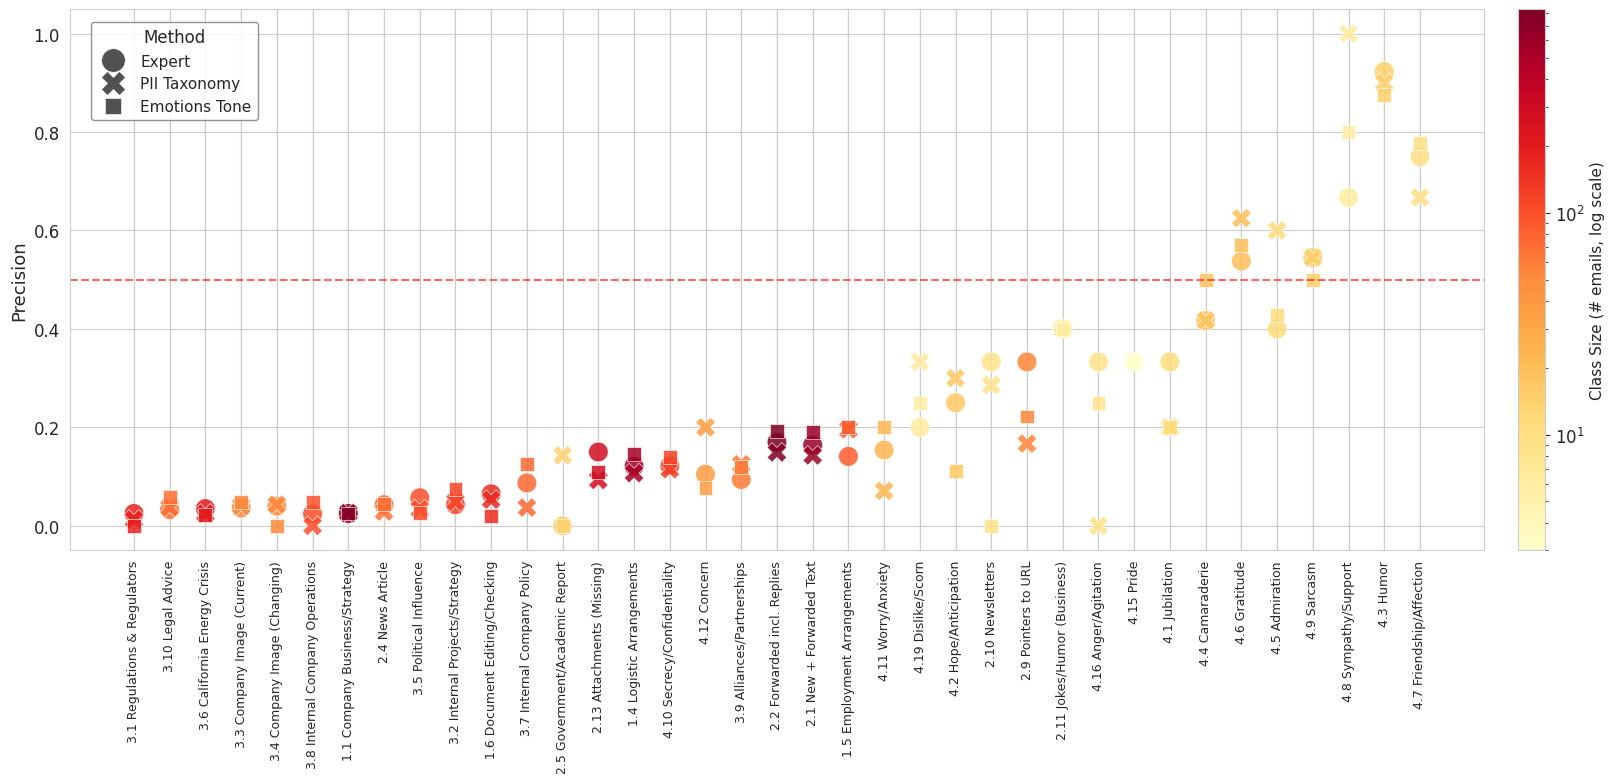

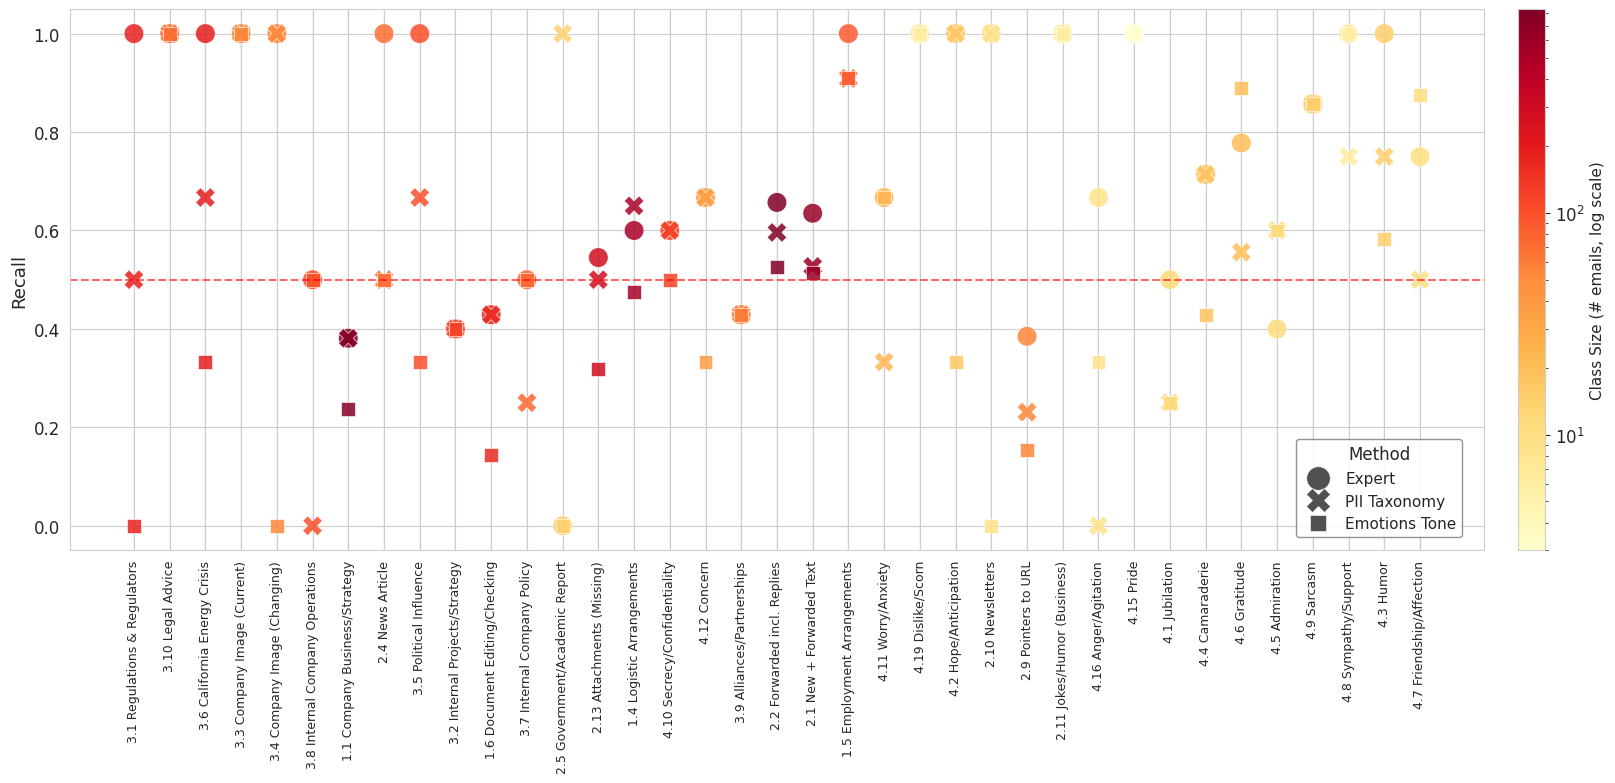

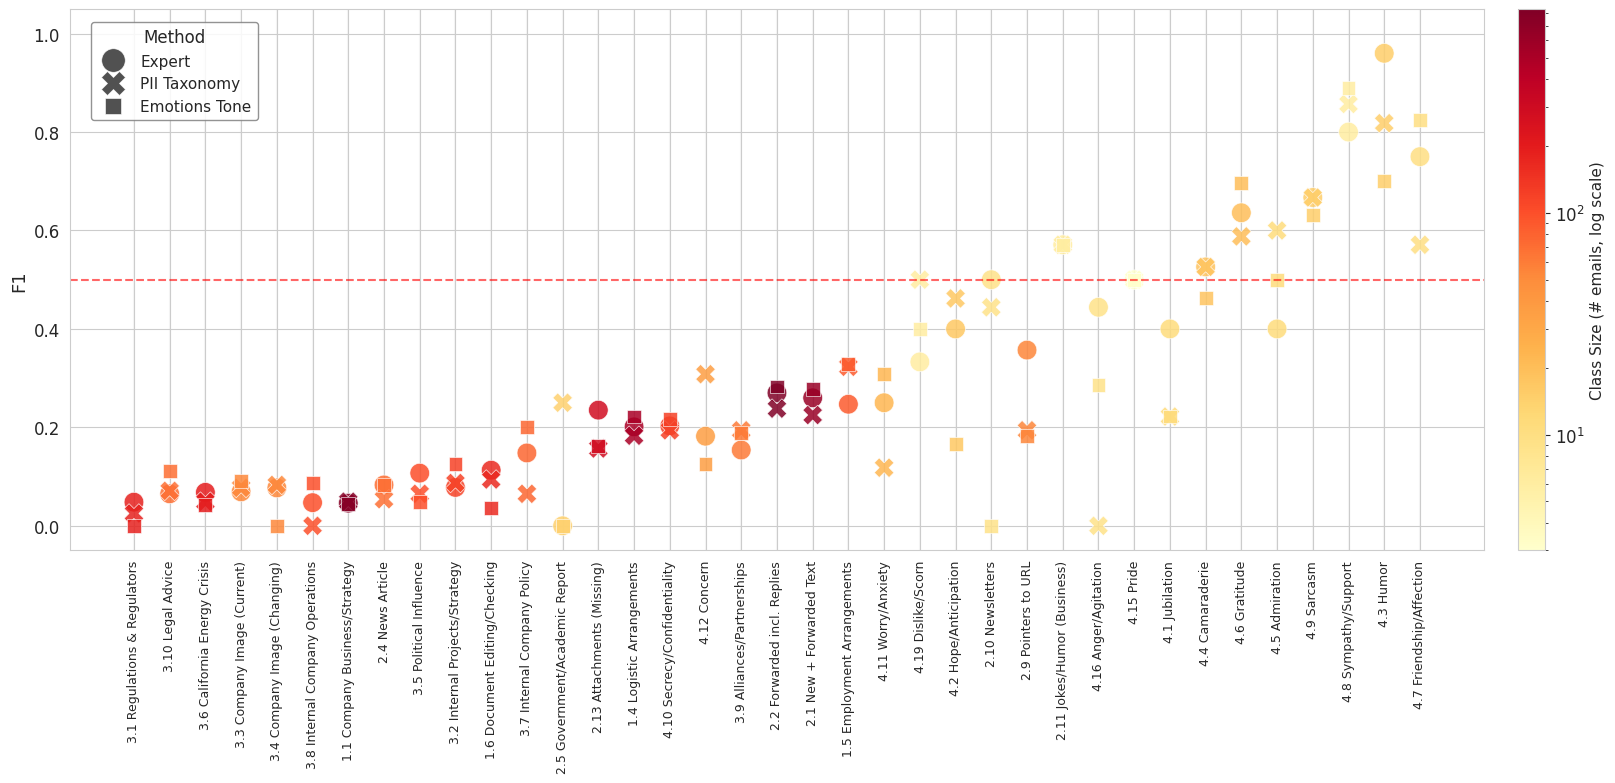

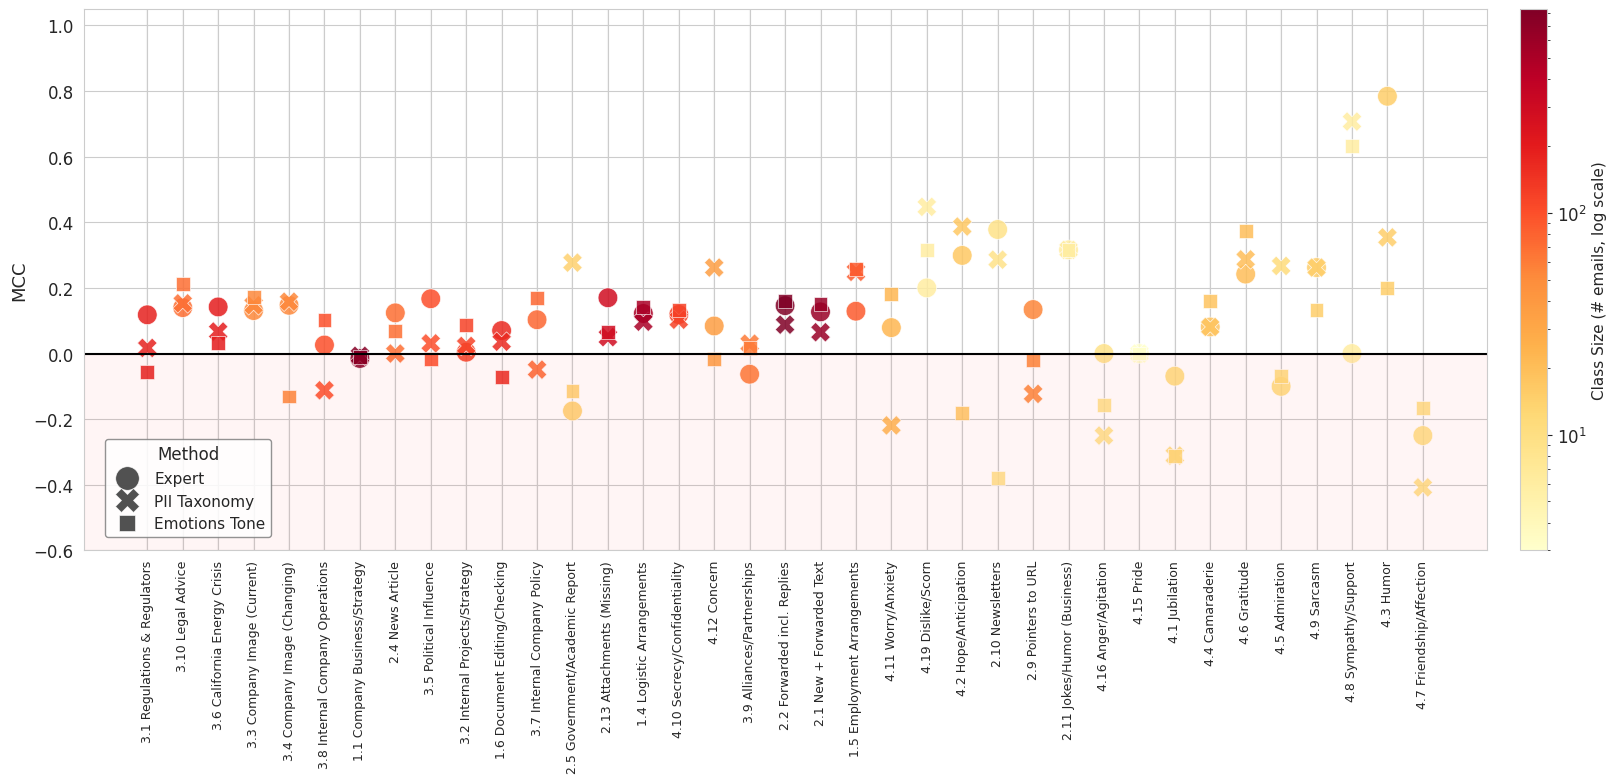

In [ ]:
method_map = {
    "Expert": dev_full,
    "PII Taxonomy": tax_full,
    "Emotions Tone": emotions_full,
}

label_map = {
    "label_1_1": "1.1 Company Business/Strategy",
    "label_1_4": "1.4 Logistic Arrangements",
    "label_1_5": "1.5 Employment Arrangements",
    "label_1_6": "1.6 Document Editing/Checking",
    "label_1_7": "1.7 Empty (Missing Attachment)",
    "label_1_8": "1.8 Empty Message",
    "label_2_1": "2.1 New + Forwarded Text",
    "label_2_2": "2.2 Forwarded incl. Replies",
    "label_2_3": "2.3 Business Letter/Document",
    "label_2_4": "2.4 News Article",
    "label_2_5": "2.5 Government/Academic Report",
    "label_2_6": "2.6 Government Action",
    "label_2_7": "2.7 Press Release",
    "label_2_8": "2.8 Legal Documents",
    "label_2_9": "2.9 Pointers to URL",
    "label_2_10": "2.10 Newsletters",
    "label_2_11": "2.11 Jokes/Humor (Business)",
    "label_2_12": "2.12 Jokes/Humor (Non-Business)",
    "label_2_13": "2.13 Attachments (Missing)",
    "label_3_1": "3.1 Regulations & Regulators",
    "label_3_2": "3.2 Internal Projects/Strategy",
    "label_3_3": "3.3 Company Image (Current)",
    "label_3_4": "3.4 Company Image (Changing)",
    "label_3_5": "3.5 Political Influence",
    "label_3_6": "3.6 California Energy Crisis",
    "label_3_7": "3.7 Internal Company Policy",
    "label_3_8": "3.8 Internal Company Operations",
    "label_3_9": "3.9 Alliances/Partnerships",
    "label_3_10": "3.10 Legal Advice",
    "label_3_11": "3.11 Talking Points",
    "label_3_12": "3.12 Meeting Minutes",
    "label_3_13": "3.13 Trip Reports",
    "label_4_1": "4.1 Jubilation",
    "label_4_2": "4.2 Hope/Anticipation",
    "label_4_3": "4.3 Humor",
    "label_4_4": "4.4 Camaraderie",
    "label_4_5": "4.5 Admiration",
    "label_4_6": "4.6 Gratitude",
    "label_4_7": "4.7 Friendship/Affection",
    "label_4_8": "4.8 Sympathy/Support",
    "label_4_9": "4.9 Sarcasm",
    "label_4_10": "4.10 Secrecy/Confidentiality",
    "label_4_11": "4.11 Worry/Anxiety",
    "label_4_12": "4.12 Concern",
    "label_4_13": "4.13 Competitiveness/Aggressiveness",
    "label_4_14": "4.14 Triumph/Gloating",
    "label_4_15": "4.15 Pride",
    "label_4_16": "4.16 Anger/Agitation",
    "label_4_17": "4.17 Sadness/Despair",
    "label_4_18": "4.18 Shame",
    "label_4_19": "4.19 Dislike/Scorn"
}

label_cols = [c for c in dev_full.columns if c.startswith("label_")]
label_cols = [c for c in label_cols if c not in ("label_1_2", "label_1_3")]

internal_splits = {}
class_sizes = {}
for col in label_cols:
    seg = dev_full[dev_full[col] == 1]
    internal_splits[col] = (seg["true_label"].str.lower() == "yes").sum() / len(seg) if len(seg) > 0 else 0
    class_sizes[col] = len(seg)

all_results = []

for name, m_df in method_map.items():
    y_pred     = m_df["sara"].str.lower().map({"yes": 1, "no": 0}).fillna(0).astype(int)
    y_true_all = m_df["true_label"].str.lower().map({"yes": 1, "no": 0}).fillna(0).astype(int)

    for col in label_cols:
        mask = m_df[col].fillna(0).astype(int) == 1
        if mask.sum() == 0:
            continue

        yt = y_true_all[mask]
        yp = y_pred[mask]

        if yt.nunique() < 2:
            all_results.append({
                "Method": name,
                "Subclass": label_map.get(col, col.replace("label_", "")),
                "BAC": np.nan, "Precision": np.nan, "Recall": np.nan,
                "F1": np.nan, "MCC": np.nan,
                "Internal_Split": internal_splits[col],
                "n_emails": class_sizes[col]
            })
            continue

        all_results.append({
            "Method":         name,
            "Subclass":       label_map.get(col, col.replace("label_", "")),
            "BAC":            round(balanced_accuracy_score(yt, yp), 3),
            "Precision":      round(precision_score(yt, yp, zero_division=0), 3),
            "Recall":         round(recall_score(yt, yp, zero_division=0), 3),
            "F1":             round(f1_score(yt, yp, zero_division=0), 3),
            "MCC":            round(matthews_corrcoef(yt, yp), 3),
            "Internal_Split": internal_splits[col],
            "n_emails":       class_sizes[col]
        })

plot_df = pd.DataFrame(all_results)

valid_subclasses = (
    plot_df.groupby("Subclass")["MCC"]
    .apply(lambda x: x.notna().any())
)
valid_subclasses = valid_subclasses[valid_subclasses].index.tolist()
plot_df = plot_df[plot_df["Subclass"].isin(valid_subclasses)]

sorted_order = (
    plot_df.groupby("Subclass")["Internal_Split"]
    .first().sort_values().index.tolist()
)
plot_df["Subclass"] = pd.Categorical(plot_df["Subclass"], categories=sorted_order, ordered=True)

metrics  = ["BAC", "Precision", "Recall", "F1", "MCC"]
n_min    = plot_df["n_emails"].min()
n_max    = plot_df["n_emails"].max()
log_norm = LogNorm(vmin=max(n_min, 1), vmax=n_max)

for metric in metrics:
    fig, ax = plt.subplots(figsize=(18, 8))
    sns.set_style("whitegrid")

    for x in range(len(sorted_order)):
        ax.axvline(x, color="gray", linestyle="-", alpha=0.07, zorder=0)

    sns.scatterplot(
        data=plot_df, x="Subclass", y=metric,
        hue="n_emails", hue_norm=log_norm,
        style="Method", palette="YlOrRd",
        s=200, alpha=0.85, edgecolor="white", linewidth=0.5, ax=ax
    )

    if metric == "Recall":
        legend_kwargs = dict(bbox_to_anchor=(0.99, 0.01), loc="lower right")
    elif metric in ("Precision", "F1"):
        legend_kwargs = dict(bbox_to_anchor=(0.01, 0.99), loc="upper left")
    else:
        legend_kwargs = dict(bbox_to_anchor=(0.01, 0.01), loc="lower left")

    handles, labels = ax.get_legend_handles_labels()
    method_names_list = list(method_map.keys())
    method_handles = [h for h, l in zip(handles, labels) if l in method_names_list]
    method_labels  = [l for l in labels if l in method_names_list]

    ax.legend(method_handles, method_labels, title="Method",
              **legend_kwargs, markerscale=1.2, fontsize=11,
              framealpha=0.85, edgecolor="gray")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=log_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Class Size (# emails, log scale)", fontsize=11)

    if metric == "MCC":
        ax.axhline(0, color="black", linestyle="-", linewidth=1.5)
        ax.axhspan(-1, 0, color="red", alpha=0.04)
        ax.set_ylim(-0.6, 1.05)
    else:
        ax.axhline(0.5, color="red", linestyle="--", alpha=0.6)
        ax.set_ylim(-0.05, 1.05)

    ax.set_xticks(range(len(sorted_order)))
    ax.set_xticklabels(sorted_order, rotation=90, ha="center", fontsize=9)
    ax.set_ylabel(metric, fontsize=13)
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(f"plot_{metric}.png", dpi=600, bbox_inches="tight")
    plt.show()

## Secondary Research Question: Email Size analysis

Calculates the classification performance for each method at different email length ranges. To determine if performance differs on longer emails.

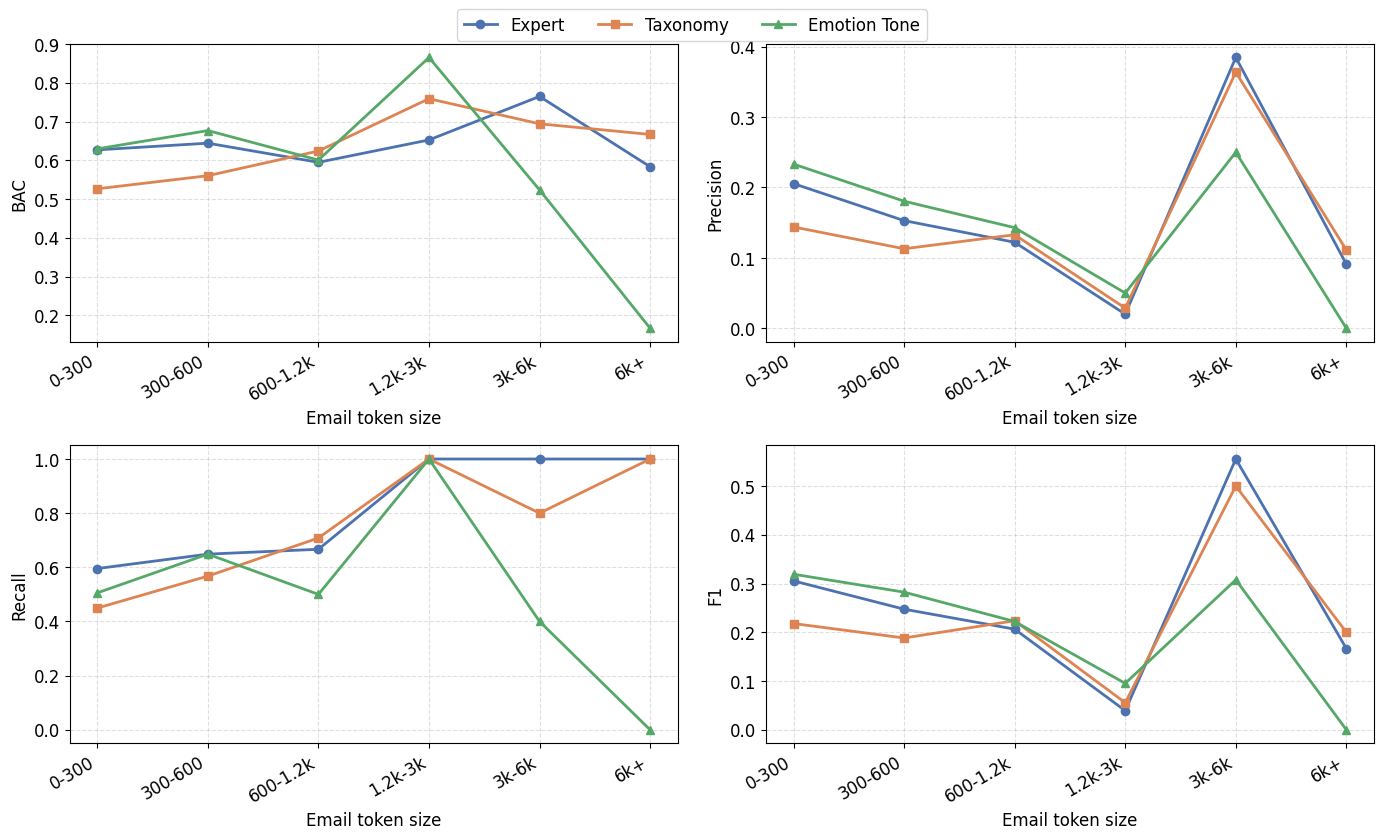

         Dataset     Range  Total  Sensitive       BAC  Precision    Recall  \
0         Expert     0-300    689         89  0.626919   0.205426  0.595506   
1         Expert   300-600    406         37  0.644108   0.152866  0.648649   
2         Expert  600-1.2k    265         24  0.594744   0.122137  0.666667   
3         Expert   1.2k-3k    143          2  0.652482   0.020000  1.000000   
4         Expert     3k-6k     22          5  0.764706   0.384615  1.000000   
5         Expert       6k+     13          1  0.583333   0.090909  1.000000   
6       Taxonomy     0-300    689         89  0.526386   0.143885  0.449438   
7       Taxonomy   300-600    406         37  0.560207   0.112903  0.567568   
8       Taxonomy  600-1.2k    265         24  0.623876   0.132812  0.708333   
9       Taxonomy   1.2k-3k    143          2  0.758865   0.028571  1.000000   
10      Taxonomy     3k-6k     22          5  0.694118   0.363636  0.800000   
11      Taxonomy       6k+     13          1  0.6666

In [27]:
def evaluate_performance(df, name):
    df = df.copy()
    mapping = {'yes': 1, 'no': 0}
    df['y_true'] = df['true_label'].str.lower().str.strip().map(mapping)
    df['y_pred'] = df['sara'].str.lower().str.strip().map(mapping)
    df = df.dropna(subset=['y_true', 'y_pred'])

    bins = [0, 300, 600, 1200, 3000, 6000, 100000]
    labels = ['0-300', '300-600', '600-1.2k', '1.2k-3k', '3k-6k', '6k+']
    df['bucket'] = pd.cut(df['token_count'], bins=bins, labels=labels)

    def get_stats(data, d_name, b_name):
        yt, yp = data['y_true'], data['y_pred']
        return {
            'Dataset': d_name,
            'Range': b_name,
            'Total': len(data),
            'Sensitive': int(yt.sum()),
            'BAC': balanced_accuracy_score(yt, yp),
            'Precision': precision_score(yt, yp, zero_division=0),
            'Recall': recall_score(yt, yp, zero_division=0),
            'F1': f1_score(yt, yp, zero_division=0)
        }

    rows = []
    for bucket, group in df.groupby('bucket', observed=False):
        if len(group) > 0:
            rows.append(get_stats(group, name, str(bucket)))
    return pd.DataFrame(rows)

datasets_to_process = {
    "Expert": dev_full,
    "Taxonomy": tax_full,
    "Emotion Tone": emotions_full
}

all_results = []
for name, dframe in datasets_to_process.items():
    all_results.append(evaluate_performance(dframe, name))

report_df = pd.concat(all_results).reset_index(drop=True)

RANGES = ['0-300', '300-600', '600-1.2k', '1.2k-3k', '3k-6k', '6k+']
DATASETS = ["Expert", "Taxonomy", "Emotion Tone"]
METRICS = ["BAC", "Precision", "Recall", "F1"]
COLORS = {"Expert": "#4C72B0", "Taxonomy": "#DD8452", "Emotion Tone": "#55A868"}
MARKERS = {"Expert": "o", "Taxonomy": "s", "Emotion Tone": "^"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, metric in zip(axes.flat, METRICS):
    for ds in DATASETS:
        sub = report_df[report_df["Dataset"] == ds].set_index("Range").reindex(RANGES)
        ax.plot(range(len(RANGES)), sub[metric].values,
                marker=MARKERS[ds], color=COLORS[ds], linewidth=2, label=ds)

    ax.set_xticks(range(len(RANGES)))
    ax.set_xticklabels(RANGES, rotation=30, ha="right")
    ax.set_ylabel(metric)
    ax.set_xlabel("Email token size")
    ax.grid(True, linestyle="--", alpha=0.4)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=3, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(f"token_size", dpi=600, bbox_inches="tight")
plt.show()

print(report_df)

## Analysis and Discussion

**Ablation Study**

Measures performance when one signal is removed for each method by recalculating final classification OR-Gate when one signal is removed.



In [ ]:
methods = {
    "Taxonomy": tax_columns,
    "Expert": dev_columns,
    "Emotions": EMOTION_COLUMNS
}

dataframes = {
    "Taxonomy": tax_full,
    "Expert": dev_full,
    "Emotions": emotions_full
}


def evaluate_subset(df, cols_to_check):
    y_true = df["true_label"].astype(str).str.strip().str.lower().map({
        'yes': 'Yes',
        'no': 'No'
    }).fillna('No')

    y_pred = df[cols_to_check].apply(
        lambda col: col.astype(str).str.strip().str.lower() == 'yes'
    ).any(axis=1).map({True: "Yes", False: "No"})

    return {
        "BAC": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="Yes", zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label="Yes", zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label="Yes", zero_division=0),
    }


all_ablation_results = []

for method_name, cols in methods.items():
    df = dataframes[method_name]

    for col in cols:
        subset = [c for c in cols if c != col]

        res = evaluate_subset(df, subset)

        res["Method"] = method_name
        res["Removed_Feature"] = col
        all_ablation_results.append(res)

df_ablation = pd.DataFrame(all_ablation_results)
df_ablation = df_ablation[["Method", "Removed_Feature", "F1", "Precision", "Recall", "BAC"]]

for method in methods:
    print(f"\n--- {method} Ablation Results ---")
    print(df_ablation[df_ablation["Method"] == method].drop(columns="Method").to_string(index=False))


--- Taxonomy Ablation Results ---
     Removed_Feature       F1  Precision   Recall      BAC
q_demographic_social 0.204082   0.125926 0.537975 0.555219
            q_belief 0.202020   0.126183 0.506329 0.552440
             q_legal 0.211321   0.131868 0.531646 0.565460
            q_health 0.197353   0.121842 0.518987 0.545363
         q_financial 0.203222   0.126348 0.518987 0.554059
           q_contact 0.147505   0.112211 0.215190 0.510131

--- Expert Ablation Results ---
     Removed_Feature       F1  Precision   Recall      BAC
  q_pp_personal_life 0.240491   0.149163 0.620253 0.607590
q_pp_personal_humour 0.234186   0.148718 0.550633 0.594882
            q_travel 0.237797   0.148206 0.601266 0.602807
               q_job 0.253444   0.161972 0.582278 0.618675
          q_opinions 0.256046   0.165138 0.569620 0.619955

--- Emotions Ablation Results ---
Removed_Feature       F1  Precision   Recall      BAC
       q_humour 0.264463   0.178971 0.506329 0.620194
   q_friendship 0.2709

## Cross Method Aggregation

Calculates performance of individual signal questions for each method. This was used for aggregation method that combined best performing signals for precision and recall.

In [ ]:
def evaluate_individual_features(df, cols_to_check, method_name):

    results = []

    y_true = df["true_label"].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0}).fillna(0)

    for col in cols_to_check:
        y_pred = df[col].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0}).fillna(0)

        predicted_yes = int(y_pred.sum())
        true_positives = int((y_pred & y_true).sum())

        precision = precision_score(y_true, y_pred, zero_division=0)

        results.append({
            "Method": method_name,
            "Question": col,
            "Predicted_Yes": predicted_yes,
            "True_Positives": true_positives,
            "Precision": precision
        })

    return results

all_individual_stats = []

for name, cols in methods.items():
    df = dataframes[name]
    stats = evaluate_individual_features(df, cols, name)
    all_individual_stats.extend(stats)

df_individual = pd.DataFrame(all_individual_stats)

for method in methods:
    print(f"\n--- {method} Individual Question Performance ---")
    subset = df_individual[df_individual["Method"] == method].drop(columns="Method")
    print(subset.to_string(index=False))


--- Taxonomy Individual Question Performance ---
            Question  Predicted_Yes  True_Positives  Precision
q_demographic_social             65              10   0.153846
            q_belief            144               8   0.055556
             q_legal            121               6   0.049587
            q_health             53              14   0.264151
         q_financial            104              16   0.153846
           q_contact            503              71   0.141153

--- Expert Individual Question Performance ---
            Question  Predicted_Yes  True_Positives  Precision
  q_pp_personal_life            121              38   0.314050
q_pp_personal_humour            240              56   0.233333
            q_travel            127              29   0.228346
               q_job            328              40   0.121951
          q_opinions            373              50   0.134048

--- Emotions Individual Question Performance ---
     Question  Predicted_Yes  Tru

Using the individual signal question performances. The aggregation approaches selecting the top 6 performing questions in terms of recall and precision are calculated.

In [ ]:

# ranks every question across all methods to find the global Top 6
df_individual_sorted_tp = df_individual.sort_values(by="True_Positives", ascending=False).head(6)
df_individual_sorted_prec = df_individual.sort_values(by="Precision", ascending=False).head(6)

# Define the Top 6 Lists
top_6_tp_cols = df_individual_sorted_tp["Question"].tolist()
top_6_prec_cols = df_individual_sorted_prec["Question"].tolist()

print(f"Top 6 by True Positives: {top_6_tp_cols}")
print(f"Top 6 by Precision: {top_6_prec_cols}\n")


master_df = dev_full.merge(
    tax_full.drop(columns=["text", "true_label", "token_count"]), on="message_id"
).merge(
    emotions_full.drop(columns=["text", "true_label", "token_count"]), on="message_id"
)

hybrid_results = []

# Test Method A: Top 6 True Positives
tp_stats = evaluate_subset(master_df, top_6_tp_cols)
tp_stats["Method"] = "Top 6 (True Positives)"
hybrid_results.append(tp_stats)

# Test Method B: Top 6 Precision
prec_stats = evaluate_subset(master_df, top_6_prec_cols)
prec_stats["Method"] = "Top 6 (Precision)"
hybrid_results.append(prec_stats)

df_hybrid = pd.DataFrame(hybrid_results)
df_hybrid = df_hybrid[["Method", "F1", "Precision", "Recall", "BAC"]]

print("--- Hybrid Aggregation Performance ---")
print(df_hybrid.to_string(index=False))



Top 6 by True Positives: ['q_contact', 'q_gratitude', 'q_pp_personal_humour', 'q_opinions', 'q_admiration', 'q_job']
Top 6 by Precision: ['q_friendship', 'q_pp_personal_life', 'q_sympathy', 'q_humour', 'q_health', 'q_camaraderie']

--- Hybrid Aggregation Performance ---
                Method       F1  Precision   Recall      BAC
Top 6 (True Positives) 0.219178   0.128068 0.759494 0.583732
     Top 6 (Precision) 0.305000   0.252066 0.386076 0.627458



## Prompt decomposition analysis
This section compares the decomposed expert-derived method against an equivalent single prompt approach that uses the same sensitivity signals. The purpose is to isolate the effect of prompt decomposition itself on classification performance, independent of the signals used.


Single prompt derived from development set, used to compare performance against decomposed prompts derived from development set

In [ ]:
def get_sara_prompt(text):
    prompt = f"""
You are analysing an email from the Enron dataset for sensitivity using the SARA dataset definition.

Your task is to classify this email as either Sensitive or Not Sensitive, strictly according to the SARA criteria.

SARA sensitivity definitions:

Sensitive emails fall into either category below.

Purely Personal:
Emails that are primarily personal and not focused on core business tasks. Examples include personal conversations unrelated to work, personal humour or jokes, social or family matters, life events such as birthdays, ageing, illness, children, personal struggles, informal personal exchanges or personal opinions unrelated to professional duties.

Personal in a Professional Context:
Emails that are mostly professional but contain personal elements about an identifiable individual. It also includes personal details such as resumes, bios, CVs, career history, job applications, referrals, interview processes, or opinions about individuals' roles or employment. Social or semi-social professional activity such as conference invitations, event participation, or social meetings outside formal work meetings are included.

Not Sensitive:
Emails that are purely professional, organisational, or logistical. This includes meeting scheduling, professional business discussions, internal company analysis, reports or forecasts, attached drafts or documents, discussions about the impact on Enrons reputation and the publics perception, business negotiations, regulatory or industry discussions, company-wide announcements, newsletters, report submissions, meeting follow-ups, calendar invites, and travel arrangements made purely for company business. Expressing opinions on company related issues is not considered not sensitive.

Important interpretation rules:
The word "Confidential" alone does not make an email sensitive. Proprietary or internal business information alone does not imply sensitivity. Phone numbers, addresses or email addresses alone do not imply sensitivity. External individuals' personal details increase the likelihood of sensitivity. Discussion of corporate reputation, public perception, regulatory risk, media scrutiny, political impact or strategic consequences for the company counts as not sensitive content.

Email:
"{text}"

Respond with ONLY "yes" (if Sensitive) or "no" (if Not Sensitive). Do not include any explanation or other text.
"""
    return prompt

Script for processing sensitivity prediction for each email from single prompt

In [ ]:
def classify_emails(
    df,
    output_path,
    model_name="gemma-3-4b-it",
    sleep_time=10,
    block_size=50
):
    if os.path.exists(output_path):
        df_out = pd.read_csv(output_path)
        print(f"Resuming from existing file: {output_path}")
    else:
        df_out = df.copy()
        df_out["sensitive"] = None

    processed = 0

    for idx, row in tqdm(df_out.iterrows(), total=len(df_out)):
        if pd.notna(row["sensitive"]):
            continue

        prompt = get_sara_prompt(row["body"])

        try:
            response = client.models.generate_content(
                model=model_name,
                contents=prompt
            )
            df_out.at[idx, "sensitive"] = response.text.strip()

        except Exception as e:
            print(f"Error on row {idx}: {e}")
            df_out.at[idx, "sensitive"] = "error"

        processed += 1

        if processed % block_size == 0:
            df_out.to_csv(output_path, index=False)
            print(f"Saved progress at {processed} processed rows")

        time.sleep(sleep_time)

    df_out.to_csv(output_path, index=False)
    print("Final save complete.")

    return df_out

Code for running each bucket on single prompt method. Each bucket had different sleep times as buckets with smaller emails could process more requests per minute

In [ ]:
output_path = "/content/drive/MyDrive/single_prompt_bucket_2000.csv"

bucket_2000_out = classify_emails(
    bucket_2000,
    output_path=output_path,
    sleep_time=8,
    block_size=50
)

output_path = "/content/drive/MyDrive/single_prompt_bucket_3500.csv"

bucket_3500_out = classify_emails(
    bucket_3500,
    output_path=output_path,
    sleep_time=16,
    block_size=1
)

output_path = "/content/drive/MyDrive/single_prompt_bucket_rest.csv"

bucket_rest_out = classify_emails(
    bucket_rest,
    output_path=output_path,
    sleep_time=60,
    block_size=1
)


Resuming from existing file: /content/drive/MyDrive/single_prompt_bucket_2000.csv


  0%|          | 0/1474 [00:00<?, ?it/s]

KeyboardInterrupt: 

Loads in the saved LLM predictions for the single prompt method.

In [ ]:
single_prompt = pd.read_csv('/content/drive/MyDrive/baseline_updated.csv') # LLM predictions for single prompt expert-derived signals

Performance of one prompt method, used to compare against decomposed version

In [ ]:
print(evaluate_sara(single_prompt))

{'balanced_accuracy': 0.6173179233168227, 'precision': 0.18269230769230768, 'recall': 0.4810126582278481, 'f1': 0.26480836236933797}


Mcnemars comparison of single prompt against decomposed expert derived methods performance

In [ ]:
print(mcnemar_comparison(single_prompt,dev_full))

{'table': [[np.int64(805), np.int64(311)], [np.int64(107), np.int64(315)]], 'b': np.int64(311), 'c': np.int64(107), 'p_value': np.float64(3.636187345959935e-24)}


## Downstream Retrieval Analysis

Gets Qrels and Queries from SARA dataset



In [ ]:
docstore = dataset.docs_store()

queries_df = pd.DataFrame(dataset.queries_iter()) # columns: [query_id, text]
qrels_df = pd.DataFrame(dataset.qrels_iter())     # columns: [query_id, doc_id, relevance, iteration]

# 3. Merge Queries and Qrels first (Join on query_id)
combined_df = pd.merge(qrels_df, queries_df, on="query_id")

combined_df['doc_text'] = combined_df['doc_id'].apply(lambda x: docstore.get(x).text)

combined_df = combined_df.rename(columns={'text': 'query_text'})

[INFO] If you have a local copy of https://raw.githubusercontent.com/JackMcKechnie/SARA-A-Collection-of-Sensitivity-Aware-Relevance-Assessments/main/repeated_queries.tsv, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/fc0247928a0b93bb344068fa238a5e3f
[INFO] [starting] https://raw.githubusercontent.com/JackMcKechnie/SARA-A-Collection-of-Sensitivity-Aware-Relevance-Assessments/main/repeated_queries.tsv
[INFO] [finished] https://raw.githubusercontent.com/JackMcKechnie/SARA-A-Collection-of-Sensitivity-Aware-Relevance-Assessments/main/repeated_queries.tsv: [00:00] [8.19kB] [4.54MB/s]
[INFO] If you have a local copy of https://raw.githubusercontent.com/JackMcKechnie/SARA-A-Collection-of-Sensitivity-Aware-Relevance-Assessments/main/repeated_qrels.txt, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/49589ab65d1eaf78dbbadfc5ae56ef72
[INFO] [starting] https://raw.githubusercontent.com/JackMcKechnie/SARA-A-Collection-of-Sens

Collects all the emails that are relevent to at least one of the SARA queries (this is 301 emails total)

In [ ]:
unique_docs_set = set(qrels_df["doc_id"].astype(int))
unique_dev = set(dev_full["doc_id"])

common_docs = unique_docs_set.intersection(unique_dev)

count_common = len(common_docs)

print(f"Number of unique qrels doc_ids found in dev_full: {count_common}")

relevant_qrels = qrels_df[qrels_df["relevance"] >= 1].copy()

relevant_qrels["doc_id_int"] = pd.to_numeric(relevant_qrels["doc_id"], errors='coerce')

eval_set = relevant_qrels[relevant_qrels["doc_id_int"].isin(common_docs)].copy()

eval_set = eval_set.drop(columns=["doc_id_int"])

print(f"Total relevant pairs found: {len(eval_set)}")
print(f"Unique queries in evaluation: {eval_set['query_id'].nunique()}")
print(eval_set["doc_id"].nunique())

Number of unique qrels doc_ids found in dev_full: 532
Total relevant pairs found: 1254
Unique queries in evaluation: 150
301


Filters the predictions for each method to only include the emails that were relevant to at least one of the queries

In [ ]:

target_ids = set(eval_set["doc_id"].astype(int))

#Filters methods to only include relevant emails
dev_filtered = dev_full[dev_full["doc_id"].astype(int).isin(target_ids)].copy()
tax_filtered = tax_full[tax_full["doc_id"].astype(int).isin(target_ids)].copy()
emotions_filtered = emotions_full[emotions_full["doc_id"].astype(int).isin(target_ids)].copy()




Performance for each of the methods on relevant emails only

In [ ]:
print("External PII Taxonomy Derived Performance")
print(evaluate_sara(tax_filtered))
print("Emotion and Tone derived performance")
print(evaluate_sara(emotions_filtered))
print("Expert-Derived Performance")
print(evaluate_sara(dev_filtered))

External PII Taxonomy Derived Performance
{'balanced_accuracy': 0.5911066355734578, 'precision': 0.375, 'recall': 0.6067415730337079, 'f1': 0.463519313304721}
Emotion and Tone derived performance
{'balanced_accuracy': 0.6196205215179139, 'precision': 0.4260869565217391, 'recall': 0.550561797752809, 'f1': 0.4803921568627451}
Expert-Derived Performance
{'balanced_accuracy': 0.561691753232987, 'precision': 0.3411764705882353, 'recall': 0.651685393258427, 'f1': 0.44787644787644787}


Using BM25 as a baseline, each models sensitivity predictions are used to post filter out sensitive emails after a BM25 ranking. Additionally an oracle is used that removes all sensitive emails to show the perfect Sensitivity Aware Search performance.

The custom metric sens@10 is defined to show the average number of sensitve documents in top 10 after ranking and filtering.

Map and nDCG@10 are used to show retrieval performance against sens@10

In [ ]:
tqdm.pandas()

# Load index and base retriever
index = pt.Artifact.from_hf('JackMcKechnie/sara_small_full_doc_v2.terrier')
bm25 = index.bm25()

# Rename columns to match PyTerrier's expected format
queries_df = queries_df.rename(columns={'query_id': 'qid', 'text': 'query'})
queries_df['qid'] = queries_df['qid'].astype(str)

qrels_df = qrels_df.rename(columns={
    'query_id': 'qid',
    'doc_id': 'docno',
    'relevance': 'label'
})
qrels_df['qid'] = qrels_df['qid'].astype(str)
qrels_df['label'] = qrels_df['label'].astype(int)

for df in [tax_full, emotions_full, dev_full]:
    df.rename(columns={'doc_id': 'docno'}, inplace=True)
    df['docno'] = df['docno'].astype(str)

test_docnos = set(tax_full["docno"])

print(tax_full.columns.tolist())
print(tax_full['docno'].dtype)



def make_sensitivity_transformer(predictions_df):

    def apply_sensitivity(run):
        run = run.merge(
            predictions_df[['docno', 'sara', 'true_label']],
            on='docno', how='left'
        )
        run['sensitivity'] = (run['sara'] == 'yes').astype(int)
        return run[run['sensitivity'] == 0].drop(columns=['sara', 'sensitivity'])

    return pt.apply.generic(apply_sensitivity)


def make_oracle_transformer(predictions_df):

    def apply_oracle(run):
        run = run.merge(
            predictions_df[['docno', 'true_label']],
            on='docno', how='left'
        )
        return run[run['true_label'] != 'yes']

    return pt.apply.generic(apply_oracle)


def add_true_labels(predictions_df):

    def apply_(run):
        run = run.merge(
            predictions_df[['docno', 'true_label']],
            on='docno', how='left'
        )
        return run

    return pt.apply.generic(apply_)



def has_sensitive_emails(qrels: pd.DataFrame, run: pd.DataFrame) -> float:
    #Total number of sensitive documents in the retrieved results.
    return (run['true_label'] == 'yes').sum()

HasSensitiveEmails = define_byquery(has_sensitive_emails, name='HasSensitiveEmails')


def sensitive_at_10(qrels: pd.DataFrame, run: pd.DataFrame) -> float:
    #Number of sensitive documents in the top 10 ranked results.
    top_10 = run.sort_values('rank').head(10)
    return (top_10['true_label'] == 'yes').sum()

SensAt10 = define_byquery(sensitive_at_10, name='Sens@10')


def filter_to_test_set(run):
    return run[run['docno'].isin(test_docnos)]

filter_transformer = pt.apply.generic(filter_to_test_set)



pipeline_bm25     = bm25 >> filter_transformer >> add_true_labels(tax_full)
pipeline_tax      = bm25 >> filter_transformer >> make_sensitivity_transformer(tax_full)
pipeline_emotions = bm25 >> filter_transformer >> make_sensitivity_transformer(emotions_full)
pipeline_dev      = bm25 >> filter_transformer >> make_sensitivity_transformer(dev_full)
pipeline_oracle   = bm25 >> filter_transformer >> make_oracle_transformer(tax_full)



results = pt.Experiment(
    [
        pipeline_bm25,
        pipeline_tax,
        pipeline_emotions,
        pipeline_dev,
        pipeline_oracle,
    ],
    queries_df,
    qrels_df,
    eval_metrics=["map", "ndcg_cut_10", HasSensitiveEmails, SensAt10],
    names=["BM25", "External Taxonomies", "Emotion Tone", "Expert-Derived", "Oracle"],
    verbose=True
)

print(results)
RESULTS_PATH = '/content/drive/MyDrive/retrieval_results.csv'
results.to_csv(RESULTS_PATH, index=False)
print(f"Results saved to {RESULTS_PATH}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


https://huggingface.co/datasets/JackMcKechnie/sara_small_full_doc_v2.terrier/resolve/main/artifact.tar.lz4:   …

extracting data.direct.bf [440.1 KB]
extracting data.document.fsarrayfile [28.3 KB]
extracting data.inverted.bf [491.3 KB]
extracting data.lexicon.fsomapfile [2.0 MB]
extracting data.lexicon.fsomaphash [1017 B]
extracting data.lexicon.fsomapid [96.0 KB]
extracting data.meta-0.fsomapfile [108.0 KB]
extracting data.meta.idx [13.3 KB]
extracting data.meta.zdata [624.5 KB]
extracting data.properties [4.1 KB]
extracting pt_meta.json [79 B]
terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


...

Done


Java started (triggered by Retriever.__init__) and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


['docno', 'text', 'sensitivity', 'true_label', 'body', 'token_count', 'q_demographic_social', 'q_belief', 'q_legal', 'q_health', 'q_financial', 'q_contact', 'sara', 'num_tax_yes', 'sara_1plus', 'sara_2plus', 'sara_3plus', 'sara_4plus', 'sara_5plus', 'sara_6plus', 'sara_7plus', 'sara_8plus', 'message_id', 'label_1_1', 'label_1_2', 'label_1_3', 'label_1_4', 'label_1_5', 'label_1_6', 'label_1_7', 'label_1_8', 'label_2_1', 'label_2_2', 'label_2_3', 'label_2_4', 'label_2_5', 'label_2_6', 'label_2_7', 'label_2_8', 'label_2_9', 'label_2_10', 'label_2_11', 'label_2_12', 'label_2_13', 'label_3_1', 'label_3_2', 'label_3_3', 'label_3_4', 'label_3_5', 'label_3_6', 'label_3_7', 'label_3_8', 'label_3_9', 'label_3_10', 'label_3_11', 'label_3_12', 'label_3_13', 'label_4_1', 'label_4_2', 'label_4_3', 'label_4_4', 'label_4_5', 'label_4_6', 'label_4_7', 'label_4_8', 'label_4_9', 'label_4_10', 'label_4_11', 'label_4_12', 'label_4_13', 'label_4_14', 'label_4_15', 'label_4_16', 'label_4_17', 'label_4_18', '

pt.Experiment:   0%|          | 0/5 [00:00<?, ?system/s]

                  name   Sens@10  HasSensitiveEmails       map  ndcg_cut_10
0                 BM25  1.460000           87.946667  0.132021     0.168317
1  External Taxonomies  0.300000           40.786667  0.078403     0.138619
2         Emotion Tone  0.566667           39.153333  0.097760     0.152333
3       Expert-Derived  0.380000           31.206667  0.069875     0.126714
4               Oracle  0.000000            0.000000  0.106852     0.165673
Results saved to /content/drive/MyDrive/retrieval_results.csv


The results for the different methods alongside the oracle and base BM25 with no filtering are compared. Showing MAP and nDCG@10 against sens@10

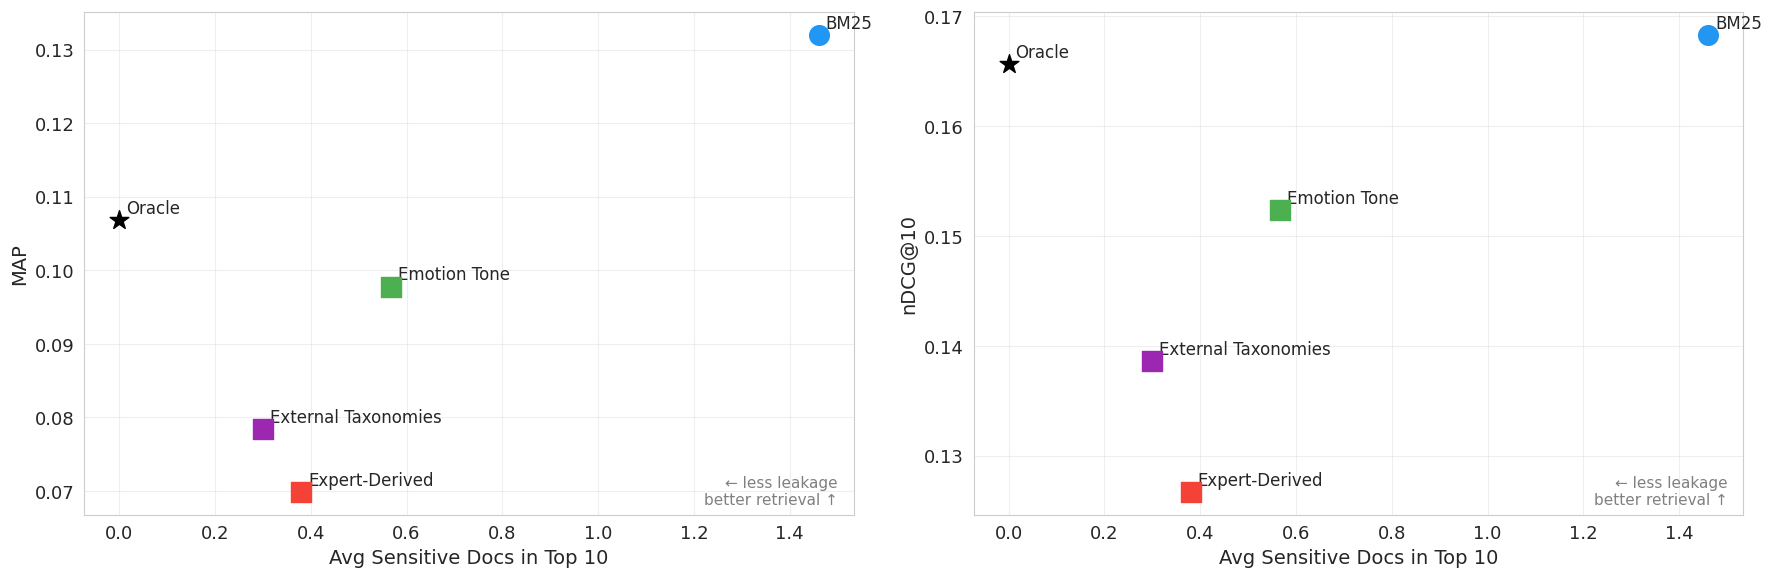

In [ ]:
method_names = ["BM25", "External Taxonomies", "Emotion Tone", "Expert-Derived", "Oracle"]

map_scores    = results.set_index('name').loc[method_names, 'map'].tolist()
ndcg_scores   = results.set_index('name').loc[method_names, 'ndcg_cut_10'].tolist()
sensitive_10  = results.set_index('name').loc[method_names, 'Sens@10'].tolist()

colors  = ['#2196F3', '#9C27B0', '#4CAF50', '#F44336', '#000000']
markers = ['o', 's', 's', 's', '*']

plt.rcParams.update({'font.size': 14})

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


# Plot 1: MAP vs Sens@10

ax1 = axes[0]
for i, name in enumerate(method_names):
    ax1.scatter(sensitive_10[i], map_scores[i], color=colors[i],
                marker=markers[i], s=200, zorder=5)
    ax1.annotate(name, (sensitive_10[i], map_scores[i]),
                 textcoords="offset points", xytext=(5, 5), fontsize=12)

ax1.set_xlabel('Avg Sensitive Docs in Top 10', fontsize=14)
ax1.set_ylabel('MAP', fontsize=14)
ax1.tick_params(axis='both', labelsize=13)
ax1.grid(True, alpha=0.3)
ax1.annotate('← less leakage\nbetter retrieval ↑', xy=(0.98, 0.02),
             xycoords='axes fraction', ha='right', fontsize=11, color='gray')


# Plot 2: nDCG@10 vs Sens@10

ax2 = axes[1]
for i, name in enumerate(method_names):
    ax2.scatter(sensitive_10[i], ndcg_scores[i], color=colors[i],
                marker=markers[i], s=200, zorder=5)
    ax2.annotate(name, (sensitive_10[i], ndcg_scores[i]),
                 textcoords="offset points", xytext=(5, 5), fontsize=12)

ax2.set_xlabel('Avg Sensitive Docs in Top 10', fontsize=14)
ax2.set_ylabel('nDCG@10', fontsize=14)
ax2.tick_params(axis='both', labelsize=13)
ax2.grid(True, alpha=0.3)
ax2.annotate('← less leakage\nbetter retrieval ↑', xy=(0.98, 0.02),
             xycoords='axes fraction', ha='right', fontsize=11, color='gray')

plt.tight_layout()
plt.savefig('retrieval_plot.png', dpi=300, bbox_inches='tight')
plt.show()

For every SARA query, the code collects all the emails relevant to that query and calculates the classification performance for the emails that were relevant to that query.

In [ ]:
def evaluate_with_confusion_matrix(eval_df, pred_df):
    mapping = {'yes': 1, 'no': 0}
    pred_df = pred_df.copy()

    pred_df['y_pred'] = pred_df['sara'].astype(str).str.lower().map(mapping)
    pred_df['y_true_binary'] = pred_df['true_label'].astype(str).str.lower().map(mapping)
    eval_df['doc_id'] = eval_df['doc_id'].astype(str)
    pred_df['doc_id'] = pred_df['doc_id'].astype(str)

    merged = pd.merge(eval_df[['query_id', 'doc_id']], pred_df[['doc_id', 'y_true_binary', 'y_pred']], on='doc_id', how='inner')

    results = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for q_id, group in merged.groupby('query_id'):
            y_true = group['y_true_binary']
            y_pred = group['y_pred']

            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

            results.append({
                'query_id': q_id,
                'TP': int(tp),
                'FP': int(fp),
                'TN': int(tn),
                'FN': int(fn),
                'Total_Docs': len(group),
                'Sensitive_Count': int(y_true.sum()),
                'F1': round(f1_score(y_true, y_pred, zero_division=0), 2),
                'Recall': round(recall_score(y_true, y_pred, zero_division=0), 2),
                'Precision': round(precision_score(y_true, y_pred, zero_division=0), 2),
                'BAC': round(balanced_accuracy_score(y_true, y_pred), 2) if len(set(y_true)) > 1 else 0.5,
                'MCC': round(matthews_corrcoef(y_true, y_pred), 2)
            })

    return pd.DataFrame(results)

query_analysis_tax = evaluate_with_confusion_matrix(eval_set, tax_filtered)
query_analysis_emotions = evaluate_with_confusion_matrix(eval_set, emotions_filtered)
query_analysis_dev = evaluate_with_confusion_matrix(eval_set, dev_filtered)
queries_df = queries_df.rename(columns={'qid': 'query_id', 'query': 'text'})

In [ ]:
def analyse_model_extremes(query_analysis_df, queries_text_df):
    performance_with_text = query_analysis_df.merge(queries_text_df, on='query_id', how='left')

    cols_to_show = [
        'query_id', 'MCC', 'F1', 'Precision', 'Recall', 'BAC',
        'TP', 'FP', 'TN', 'FN', 'Sensitive_Count', 'text'
    ]

    final_cols = [c for c in cols_to_show if c in performance_with_text.columns]
    df_display = performance_with_text[final_cols]

    print("TOP 5 PERFORMING QUERIES (By MCC)")
    top_5 = df_display.sort_values(by='MCC', ascending=False).head(5)
    display(top_5)

    print("BOTTOM 5 PERFORMING QUERIES (By MCC)")
    bottom_5 = df_display.sort_values(by='MCC', ascending=True).head(5)
    display(bottom_5)

    return performance_with_text

print("Taxonomy Method per query performance")
tax_with_text = analyse_model_extremes(query_analysis_tax, queries_df)
print("Emotion Method per query performance")
emotions_with_text = analyse_model_extremes(query_analysis_emotions, queries_df)
print("Expert-derived method per query performance")
dev_with_text = analyse_model_extremes(query_analysis_dev, queries_df)


Taxonomy Method per query performance
TOP 5 PERFORMING QUERIES (By MCC)


,query_id,MCC,F1,Precision,Recall,BAC,TP,FP,TN,FN,Sensitive_Count,text
21,118,1.00,1.00,1.0,1.00,1.00,1,0,1,0,1,What was Joanna Vidal job and what role did sh...
22,119,1.00,1.00,1.0,1.00,1.00,1,0,1,0,1,Enron events Joanna Vidal and work
24,120,1.00,1.00,1.0,1.00,1.00,1,0,1,0,1,What events did Joanna Vidal organise for Enron
60,18,0.87,0.92,1.0,0.86,0.93,6,0,8,1,7,people who have worked for Enron and how they ...
59,17,0.87,0.92,1.0,0.86,0.93,6,0,8,1,7,"How does the hiring process work at Enron, and..."


BOTTOM 5 PERFORMING QUERIES (By MCC)


,query_id,MCC,F1,Precision,Recall,BAC,TP,FP,TN,FN,Sensitive_Count,text
53,147,-1.00,0.0,0.00,0.0,0.00,0,2,0,1,1,History breakdown of Enrons tax activities
51,145,-1.00,0.0,0.00,0.0,0.00,0,2,0,1,1,what type of taxes did enron pay
52,146,-1.00,0.0,0.00,0.0,0.00,0,2,0,1,1,what were Enrons business tax rates as an ener...
47,141,-0.38,0.2,0.12,0.5,0.31,1,7,1,1,2,Enrons influence in universities and its colla...
44,139,-0.38,0.2,0.12,0.5,0.31,1,7,1,1,2,What universities does enron work with and wha...


Emotion Method per query performance
TOP 5 PERFORMING QUERIES (By MCC)


...

,query_id,MCC,F1,Precision,Recall,BAC,TP,FP,TN,FN,Sensitive_Count,text
39,134,-1.0,0.0,0.0,0.0,0.0,0,1,0,3,3,what is the influence of Enron on Amsterdam an...
40,135,-1.0,0.0,0.0,0.0,0.0,0,1,0,3,3,Enron Amsterdam activity local
38,133,-1.0,0.0,0.0,0.0,0.0,0,1,0,3,3,How does energy work in Amsterdam enron
28,124,-0.2,0.0,0.0,0.0,0.4,0,1,4,1,1,Investor owned utilities public opinion not En...
30,126,-0.2,0.0,0.0,0.0,0.4,0,1,4,1,1,Types of investor owned utilities and similar ...


Expert-derived method per query performance
TOP 5 PERFORMING QUERIES (By MCC)


,query_id,MCC,F1,Precision,Recall,BAC,TP,FP,TN,FN,Sensitive_Count,text
21,118,1.00,1.00,1.00,1.0,1.0,1,0,1,0,1,What was Joanna Vidal job and what role did sh...
22,119,1.00,1.00,1.00,1.0,1.0,1,0,1,0,1,Enron events Joanna Vidal and work
24,120,1.00,1.00,1.00,1.0,1.0,1,0,1,0,1,What events did Joanna Vidal organise for Enron
25,121,0.83,0.92,0.86,1.0,0.9,6,1,4,0,6,What US senator and state did Enron target
26,122,0.83,0.92,0.86,1.0,0.9,6,1,4,0,6,which US states were affected by the Enron


BOTTOM 5 PERFORMING QUERIES (By MCC)


,query_id,MCC,F1,Precision,Recall,BAC,TP,FP,TN,FN,Sensitive_Count,text
44,139,-0.67,0.18,0.11,0.50,0.25,1,8,0,1,2,What universities does enron work with and wha...
46,140,-0.67,0.18,0.11,0.50,0.25,1,8,0,1,2,What are the papers published by Enron and thr...
47,141,-0.67,0.18,0.11,0.50,0.25,1,8,0,1,2,Enrons influence in universities and its colla...
9,107,-0.45,0.50,0.40,0.67,0.33,2,3,0,1,3,Kenneth Lay investigation wiki scandal
8,106,-0.45,0.50,0.40,0.67,0.33,2,3,0,1,3,What is Kenneth Lays role in Enron how did he ...


Displays the Top 5 and Bottom 5 queries based on MCC performance of the emails relevant to the queries

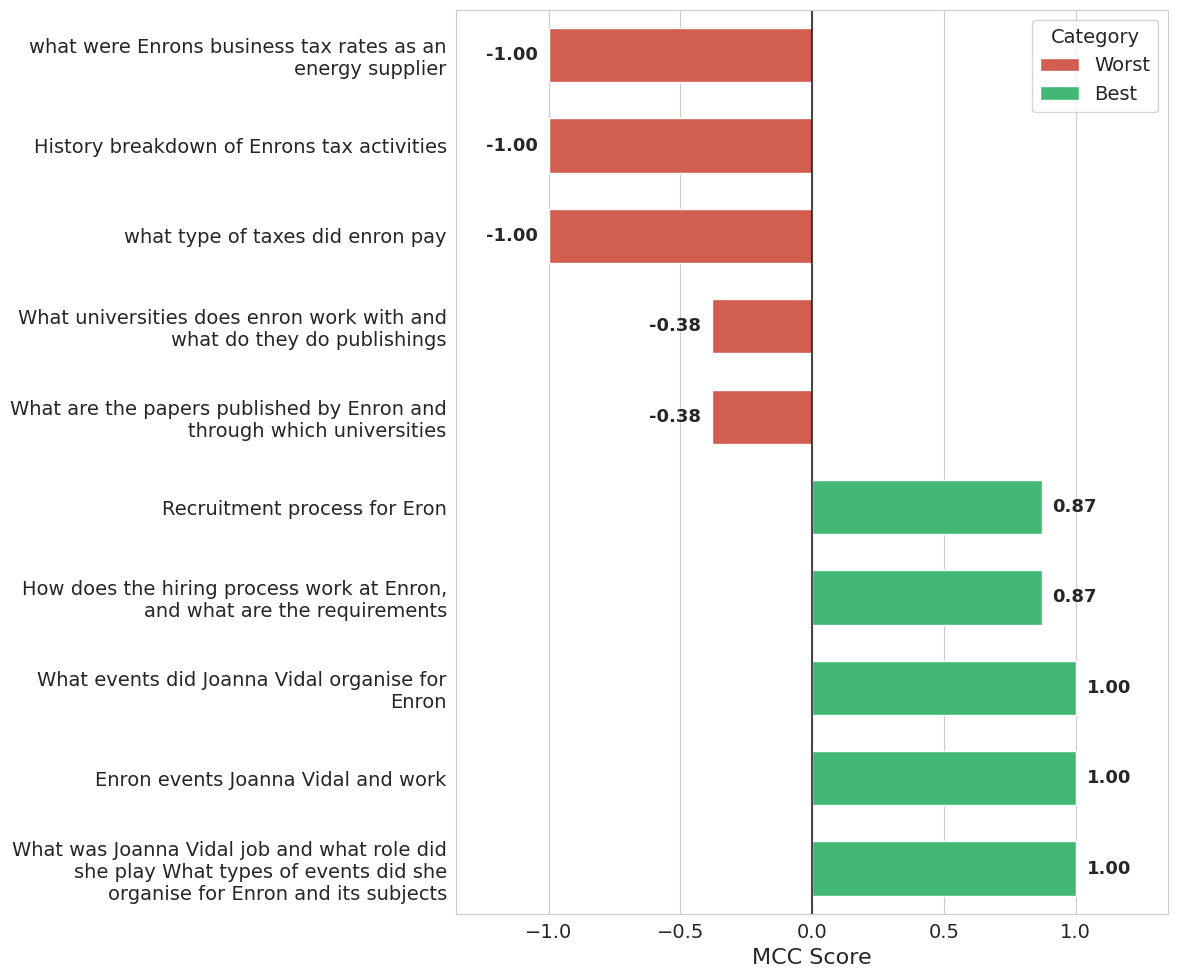

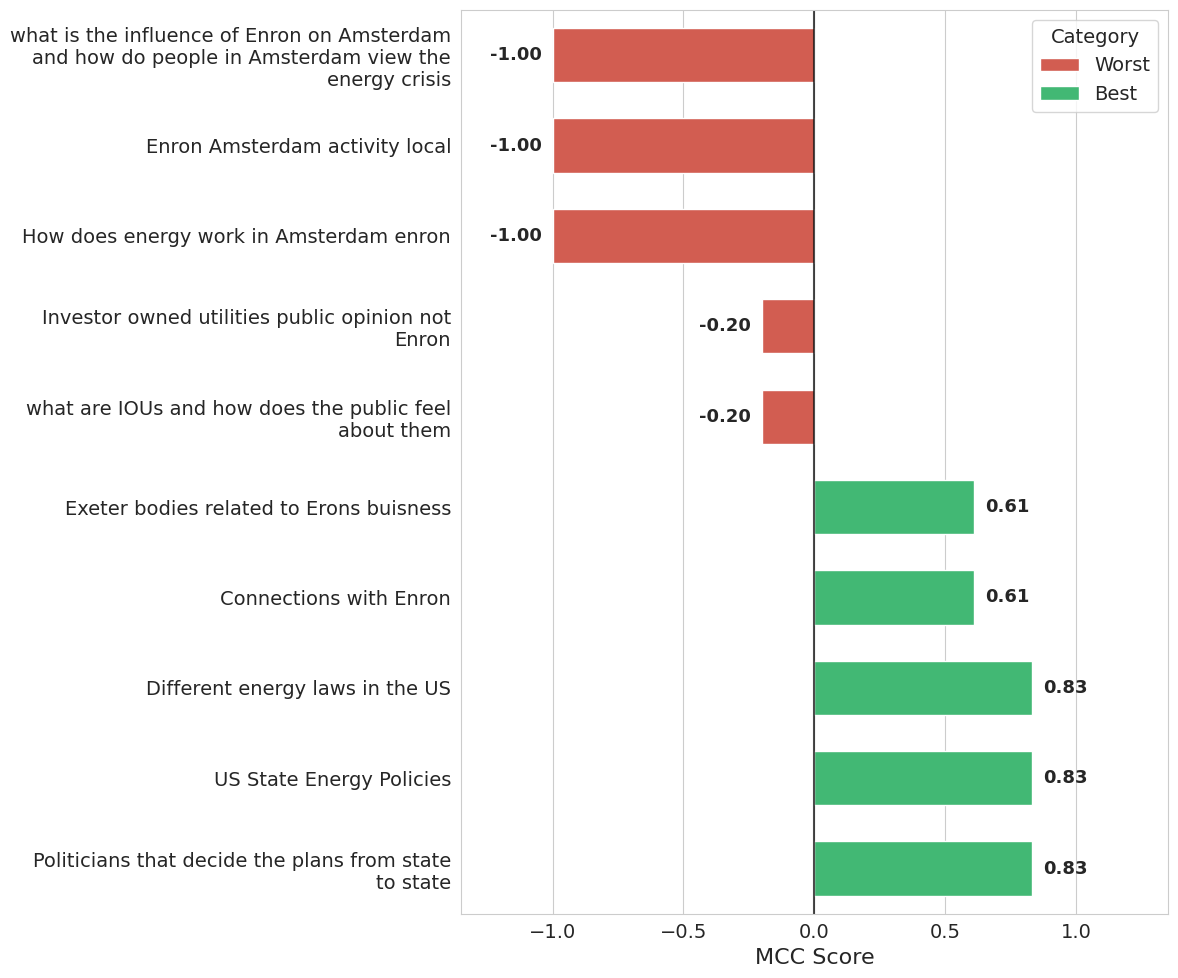

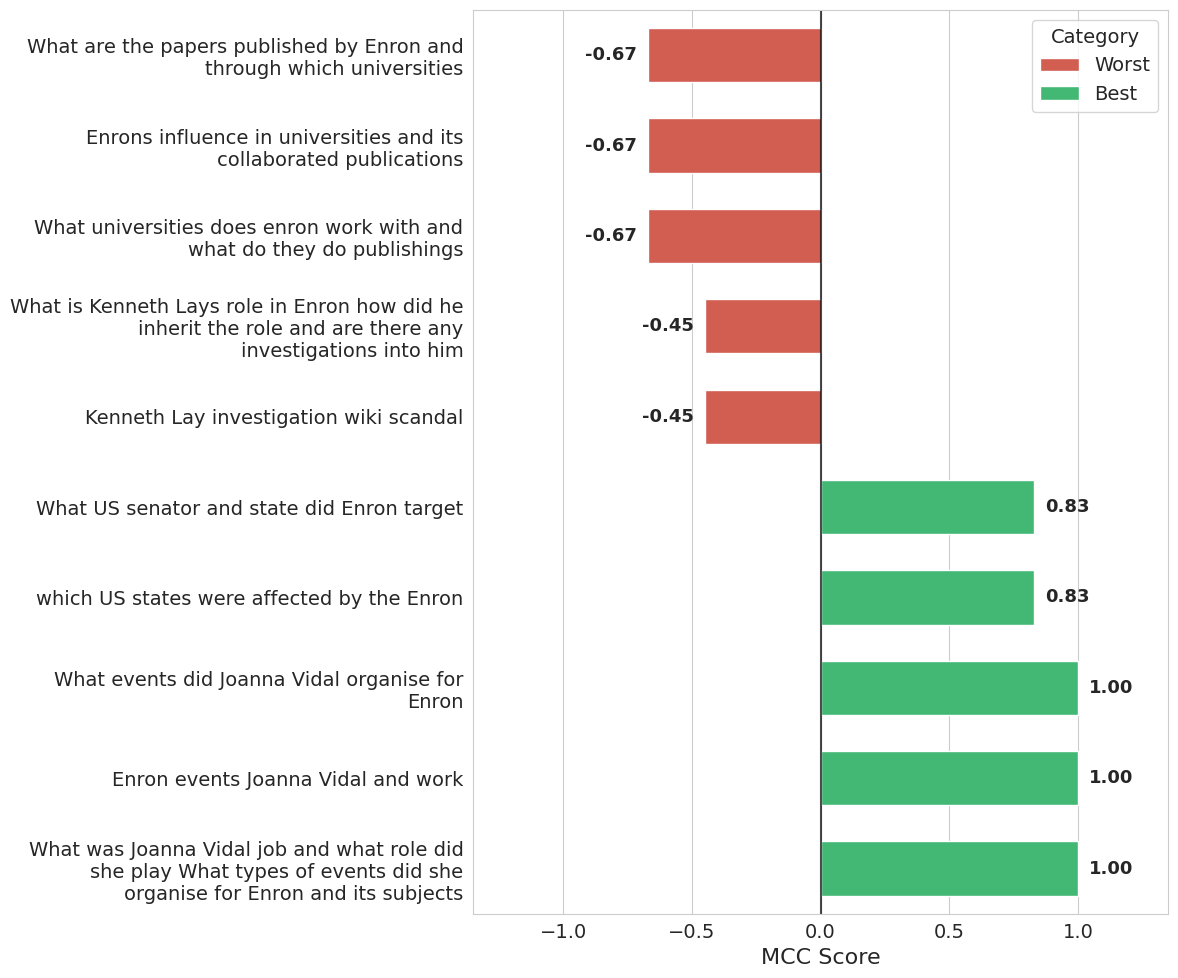

In [ ]:
def plot_mcc_extremes_with_labels(analysis_dfs, queries_text_df):
    colors = {'Best': '#2ecc71', 'Worst': '#e74c3c'}

    for name, df in analysis_dfs.items():
        fig, ax = plt.subplots(figsize=(12, 10))

        full_df = df.merge(queries_text_df, on='query_id')

        top = full_df.nlargest(5, 'MCC').copy()
        top['Category'] = 'Best'
        bottom = full_df.nsmallest(5, 'MCC').copy()
        bottom['Category'] = 'Worst'

        combined = pd.concat([top, bottom]).sort_values('MCC', ascending=True)

        combined['Wrapped_Text'] = combined['text'].apply(
            lambda x: '\n'.join(textwrap.wrap(x, width=45))
        )

        sns.barplot(
            data=combined,
            x='MCC',
            y='Wrapped_Text',
            hue='Category',
            palette=colors,
            ax=ax,
            dodge=False,
            width=0.6
        )

        for container in ax.containers:
            ax.bar_label(
                container,
                fmt='%.2f',
                padding=8,
                fontsize=13,
                fontweight='bold'
            )

        ax.set_xlim(-1.35, 1.35)
        ax.axvline(0, color='black', linewidth=1.5, alpha=0.7)
        ax.set_xlabel('MCC Score', fontsize=16)
        ax.set_ylabel('')

        ax.tick_params(axis='y', labelsize=14)

        ax.legend(title='Category', loc='upper right')

        plt.tight_layout()

        safe_name = name.lower().replace(" ", "_").replace("-", "_")
        fig.savefig(f'mcc_analysis_{safe_name}.png', dpi=600, bbox_inches='tight')
        plt.show()

methods_dict = {
    'Taxonomy': query_analysis_tax,
    'Emotion Tone': query_analysis_emotions,
    'Expert-Derived': query_analysis_dev
}

plot_mcc_extremes_with_labels(methods_dict, queries_df);